### Figures for paper

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from datetime import datetime

import geopandas as gpd
import rioxarray as rxr
import xarray as xr
import rasterio as rio
import numpy.ma as ma

import matplotlib.pyplot as plt
import contextily
import cmcrameri.cm as cmc
import matplotlib.patches as patches
from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib import rcParams
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from working_sca_funcs import create_binary_chm, extract_dates, closest_date, calc_rgb, create_validation_dataset, calculate_metrics

In [2]:
name = 'BUDD'
# Read shapefiles, create basin masks, and load validation dataset
# Read in basin shapefile and canopy mask
BS = f'/home/etboud/projects/data/basins/{name}/{name}_4326.geojson'
basin = gpd.read_file(BS).to_crs('EPSG:32611')
can = f'/home/etboud/projects/data/masks/4b_15img_ndvi_30_85_{name}_notclipped.tif'
mask = rxr.open_rasterio(can).rio.clip(basin.geometry.values, basin.crs, drop=True)
mask.values = np.where(mask.values>0, 0, 1)


# Load the bianry ASO dataset
aso_nc = f'/home/etboud/projects/data/stacks/extra/{name}_aso_projected.nc'
aso = xr.open_dataset(aso_nc)

### Binary Performance Metric Table

In [3]:
# file = '/home/etboud/projects/data/stacks/BUDD_M1_2022_projected.nc'
# model = file.split('/')[-1].split('_')[1]
# code = 0
# year =2022

def get_masked_metrics(file,model, code, year):
    corr_fn = pd.read_csv('/home/etboud/projects/snow_mapping/corresponding_files_all.csv') # have not tested yet
    corr_fn = corr_fn[corr_fn['model_run']=='V5']
    corr_fn = corr_fn.drop(columns= ['model_file', 'model_run', 'raw_file','aso_file'])
    corr_fn = corr_fn[corr_fn['aso_date'].astype(str).str[:4]== str(year)]
    corr_fn = corr_fn.sort_values(by=corr_fn.columns.tolist())
    ps = xr.open_dataset(file)
    metrics = []
    for index, row in corr_fn.iterrows():
        times = ps['data'].time.values
        target_time = np.datetime64(row['ps_date'])

        matching_indices = np.where(times == target_time)[0]
        if len(matching_indices) == 0:
            # fallback, e.g. nearest match
            diffs = np.abs(times - target_time)
            matching_indices = [diffs.argmin()]
        model_slice = ps['data'].isel(time=matching_indices[0])     
        aso_slice = aso['data'].sel(time=pd.to_datetime(row['aso_date']))


        if model_slice.shape != aso_slice.shape:
            model_slice = model_slice[1]  # Not ideal; better to handle this more explicitly

        # if '2022-05-18T00:00:00.000000000' in row['ps_date']:
        #     model_slice = np.where(~sampled_mask.isnull())

        mask_array = mask.values[0]  # shape: (Y, X)

        if code == 0:
            condition = mask_array == 0 # canopy
        elif code == 1:
            condition = mask_array == 1 # open
        elif code == 2:
            condition = ~np.isnan(mask_array) # all
        else:
            raise ValueError(f"Unsupported code: {code}")

        model_slice_masked = np.where(condition, model_slice, np.nan)
        aso_slice_masked = np.where(condition, aso_slice, np.nan)

        # Create DataFrames for predicted (model) and observed (ASO) values
        ps_df = pd.DataFrame({
            'x': [x for x in range(model_slice_masked.shape[1]) for y in range(model_slice_masked.shape[0])],
            'y': [y for x in range(model_slice_masked.shape[1]) for y in range(model_slice_masked.shape[0])],
            'predict': model_slice_masked.flatten()
        })

        aso_df = pd.DataFrame({
            'x': [x for x in range(aso_slice_masked.shape[1]) for y in range(aso_slice_masked.shape[0])],
            'y': [y for x in range(aso_slice_masked.shape[1]) for y in range(aso_slice_masked.shape[0])],
            'obs': aso_slice_masked.flatten()
        })


        df = pd.merge(aso_df, ps_df, on=['x', 'y']).dropna()
        metrics_df = calculate_metrics(df)
        metrics_df['ps_date'] = row['ps_date']
        metrics_df['aso_date'] = row['aso_date']
        metrics_df['model'] = model
        metrics_df['year'] = year
        metrics_df['code'] = code
        metrics.append(metrics_df)

    return pd.concat(metrics, ignore_index=True)
    
def extract_file_metadata(filename):
    """Extract model and year from a filename."""
    basename = os.path.basename(filename)
    parts = basename.split('_')
    model = parts[1]
    year = parts[2]
    return model, year


def run_metrics_from_files(directory, target_codes=None):
    files = glob.glob(os.path.join(directory, f"{name}_*.nc"))
    print(files)
    all_results = []

    for file in files:
        model, year = extract_file_metadata(file)
        for code in [0,1,2]: 
            df = get_masked_metrics(file=file, model = model,code=code,year=year)
            
            all_results.append(df)

    return pd.concat(all_results, ignore_index=True)

df_all = run_metrics_from_files(
    directory='/home/etboud/projects/data/stacks/sep/',
    target_codes=[0, 1, 2]
)
        

['/home/etboud/projects/data/stacks/sep/BUDD_base_2020_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_composite_2020_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseT_2022_QAQC_temporal.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseS_2022_3_30.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseST_2023_3_30.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseT_2023_QAQC_temporal.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseS_2020_3_30.nc', '/home/etboud/projects/data/stacks/sep/BUDD_compositeT_2020_QAQC_temporal.nc', '/home/etboud/projects/data/stacks/sep/BUDD_base_2022_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseST_2022_3_30.nc', '/home/etboud/projects/data/stacks/sep/BUDD_base_2023_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_composite_2022_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseT_2020_QAQC_temporal.nc', '/home/etboud/projects/data/stacks/sep/BUDD_compositeT_2022_QAQC_temporal.nc', '/

In [4]:
df_summary = df_all.groupby(['model', 'code', 'year']).mean(numeric_only=True)
df_summary.reset_index(inplace=True)
df_summary_full =df_summary

In [5]:
merged_all = df_summary
merged_all = merged_all.groupby(['model', 'code']).mean(numeric_only=True).reset_index()

In [6]:
summary = (
    merged_all
    .groupby(['model', 'code'])
    .agg({col: ['mean', 'std'] for col in merged_all.select_dtypes(include='number').columns})  # Aggregate only numeric columns
    .round(2)  # Round both mean and std to 2 decimal places
)
# Drop columns not needed
summary.drop(columns=['TN', 'TP','FN','FP','kappa'], inplace=True)
# format column values
summary.columns = ['_'.join(col).strip('_') for col in summary.columns.values]
summary = summary.reset_index()

summary['F1 Score'] = summary.apply(
    lambda row: f"{row['f1_mean']} ± {row['f1_std']}", axis=1
)
summary['Precision'] = summary.apply(
    lambda row: f"{row['precision_mean']} ± {row['precision_std']}", axis=1
)
summary['Recall'] = summary.apply(
    lambda row: f"{row['recall_mean']} ± {row['recall_std']}", axis=1
)
summary['Accuracy'] = summary.apply(
    lambda row: f"{row['accuracy_mean']} ± {row['accuracy_std']}", axis=1
)

In [7]:
final_table = summary[['model', 'code', 'F1 Score', 'Precision', 'Recall', 'Accuracy']]

#rename base to Base, baseST to Base (S+T), comeposite to Composite, compositeT to Composite (T)
final_table['model'] = final_table['model'].replace({
    'base': 'Base',
    'baseS' : 'Base (S)',
    'baseST': 'Base (S+T)',
    'composite': 'Composite',
    'compositeT': 'Composite (T)',
    # 'compositeST': 'Composite (S+T)'
})

# code 0 is 'Canopy Pixels', code 1 is 'Open Pixels', code 2 is 'All Pixels'
final_table['code'] = final_table['code'].replace({
    0: 'Canopy Pixels',
    1: 'Open Pixels',
    2: 'All Pixels'
})

/tmp/ipykernel_737519/1694592239.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_table['model'] = final_table['model'].replace({
/tmp/ipykernel_737519/1694592239.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_table['code'] = final_table['code'].replace({


In [8]:
# LaTeX for paper
print(final_table.to_latex(index=False))

\begin{tabular}{llllll}
\toprule
model & code & F1 Score & Precision & Recall & Accuracy \\
\midrule
Base & Canopy Pixels & 0.77 ± nan & 0.92 ± nan & 0.7 ± nan & 0.75 ± nan \\
Base & Open Pixels & 0.93 ± nan & 0.92 ± nan & 0.95 ± nan & 0.89 ± nan \\
Base & All Pixels & 0.86 ± nan & 0.92 ± nan & 0.82 ± nan & 0.81 ± nan \\
Base (S) & Canopy Pixels & 0.82 ± nan & 0.9 ± nan & 0.78 ± nan & 0.79 ± nan \\
Base (S) & Open Pixels & 0.93 ± nan & 0.92 ± nan & 0.95 ± nan & 0.89 ± nan \\
Base (S) & All Pixels & 0.88 ± nan & 0.91 ± nan & 0.86 ± nan & 0.83 ± nan \\
Base (S+T) & Canopy Pixels & 0.85 ± nan & 0.89 ± nan & 0.82 ± nan & 0.82 ± nan \\
Base (S+T) & Open Pixels & 0.94 ± nan & 0.91 ± nan & 0.97 ± nan & 0.9 ± nan \\
Base (S+T) & All Pixels & 0.9 ± nan & 0.91 ± nan & 0.89 ± nan & 0.85 ± nan \\
baseT & Canopy Pixels & 0.82 ± nan & 0.91 ± nan & 0.75 ± nan & 0.79 ± nan \\
baseT & Open Pixels & 0.94 ± nan & 0.91 ± nan & 0.97 ± nan & 0.89 ± nan \\
baseT & All Pixels & 0.88 ± nan & 0.92 ± nan & 0.86 

### Distance to Canopy Edge

In [5]:
dce_mask = rxr.open_rasterio('/home/etboud/projects/data/masks/dce_classes_budd.tif') #/home/etboud/projects/data/masks/dce_classes_budd.tif

In [6]:
def get_dce_metrics(file,model, code, year):
    corr_fn = pd.read_csv('/home/etboud/projects/snow_mapping/corresponding_files_all.csv') # /home/etboud/projects/snow_mapping/COPP_corresponding_files.csv
    corr_fn = corr_fn[corr_fn['model_run']=='V5']
    corr_fn = corr_fn.drop(columns= ['model_file', 'model_run', 'raw_file','aso_file'])
    corr_fn = corr_fn[corr_fn['aso_date'].astype(str).str[:4]== str(year)]
    corr_fn = corr_fn.sort_values(by=corr_fn.columns.tolist())
    ps = xr.open_dataset(file)
    metrics = []
    for index, row in corr_fn.iterrows():
        times = ps['data'].time.values
        target_time = np.datetime64(row['ps_date'])

        matching_indices = np.where(times == target_time)[0]
        if len(matching_indices) == 0:
            # fallback, e.g. nearest match
            diffs = np.abs(times - target_time)
            matching_indices = [diffs.argmin()]
        model_slice = ps['data'].isel(time=matching_indices[0])     
        aso_slice = aso['data'].sel(time=pd.to_datetime(row['aso_date']))



        if model_slice.shape != aso_slice.shape:
            model_slice = model_slice[1]  # Not ideal; better to handle this more explicitly


        mask_array = dce_mask.values[0]  # shape: (Y, X)

        if code == -1:
            condition = mask_array == -1 # dense canopy
        elif code == 0:
            condition = mask_array == 0 # forest cluster
        elif code == 1:
            condition = mask_array == 1 # forest edge
        elif code == 2:
            condition = mask_array == 2 # small gaps
        elif code == 3:
            condition = mask_array == 3 # medium gaps
        elif code == 4:
            condition = mask_array == 4 # large gaps
        elif code == 5:
            condition = mask_array == 5 # small gaps
        elif code == 6:
            condition = mask_array == 6 # small gaps
        else:
            raise ValueError(f"Unsupported code: {code}")

        model_slice_masked = np.where(condition, model_slice, np.nan)
        aso_slice_masked = np.where(condition, aso_slice, np.nan)

        # Create DataFrames for predicted (model) and observed (ASO) values
        ps_df = pd.DataFrame({
            'x': [x for x in range(model_slice_masked.shape[1]) for y in range(model_slice_masked.shape[0])],
            'y': [y for x in range(model_slice_masked.shape[1]) for y in range(model_slice_masked.shape[0])],
            'predict': model_slice_masked.flatten()
        })

        aso_df = pd.DataFrame({
            'x': [x for x in range(aso_slice_masked.shape[1]) for y in range(aso_slice_masked.shape[0])],
            'y': [y for x in range(aso_slice_masked.shape[1]) for y in range(aso_slice_masked.shape[0])],
            'obs': aso_slice_masked.flatten()
        })


        df = pd.merge(aso_df, ps_df, on=['x', 'y']).dropna()
        metrics_df = calculate_metrics(df)
        metrics_df['ps_date'] = row['ps_date']
        metrics_df['aso_date'] = row['aso_date']
        metrics_df['model'] = model
        metrics_df['year'] = year
        metrics_df['code'] = code
        metrics.append(metrics_df)

    return pd.concat(metrics, ignore_index=True)
    
def extract_file_metadata(filename):
    """Extract model and year from a filename."""
    basename = os.path.basename(filename)
    parts = basename.split('_')
    model = parts[1]
    year = parts[2]
    return model, year


def run_metrics_from_files(directory, name, target_codes=None):
    files = glob.glob(os.path.join(directory, f"{name}_*.nc"))
    print(files)
    all_results = []

    for file in files:
        if 'T_' not in file:
            model, year = extract_file_metadata(file)
            for code in [-1,0,1,2,3,4,5,6]: 
                df = get_dce_metrics(file=file, model = model,code=code,year=year)
                
                all_results.append(df)

    return pd.concat(all_results, ignore_index=True)


dce_all = run_metrics_from_files(
    directory='/home/etboud/projects/data/stacks/sep/',
    name = 'BUDD',
    target_codes=[-1,0, 1, 2,3,4,5,6]
)

['/home/etboud/projects/data/stacks/sep/BUDD_base_2020_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_composite_2020_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseT_2022_QAQC_temporal.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseS_2022_3_30.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseST_2023_3_30.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseT_2023_QAQC_temporal.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseS_2020_3_30.nc', '/home/etboud/projects/data/stacks/sep/BUDD_compositeT_2020_QAQC_temporal.nc', '/home/etboud/projects/data/stacks/sep/BUDD_base_2022_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseST_2022_3_30.nc', '/home/etboud/projects/data/stacks/sep/BUDD_base_2023_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_composite_2022_projected.nc', '/home/etboud/projects/data/stacks/sep/BUDD_baseT_2020_QAQC_temporal.nc', '/home/etboud/projects/data/stacks/sep/BUDD_compositeT_2022_QAQC_temporal.nc', '/

In [7]:
dce_all = dce_all.drop_duplicates()
backup = dce_all
dce_all = dce_all[(dce_all['model']=='base')|(dce_all['model']=='baseS')|(dce_all['model']=='composite')]

# get summary on dce all
dce_summary = dce_all.groupby(['model', 'code']).median(numeric_only=True)


In [8]:
dce_summary.drop(columns=['TN', 'TP','FN','FP','kappa', 'balanced_accuracy'], inplace=True)
# change column order
dce_summary = dce_summary[[ 'f1', 'precision', 'recall', 'accuracy']]
dce_summary = dce_summary.round(2)

In [29]:
dce_summary

f1  precision  recall  accuracy
model     code                                   
base      -1    0.62       0.98    0.45      0.60
           0    0.81       0.96    0.79      0.78
           1    0.87       0.96    0.87      0.81
           2    0.92       0.95    0.90      0.85
           3    0.94       0.94    0.95      0.89
           4    0.94       0.94    0.97      0.90
           5    0.92       0.93    0.98      0.86
           6    0.94       0.93    0.99      0.90
baseS     -1    0.70       0.98    0.54      0.64
           0    0.87       0.96    0.87      0.84
           1    0.92       0.96    0.91      0.86
           2    0.95       0.95    0.95      0.90
           3    0.95       0.94    0.97      0.90
           4    0.94       0.94    0.98      0.90
           5    0.92       0.93    0.99      0.87
           6    0.94       0.93    0.99      0.90
composite -1    0.75       0.98    0.63      0.63
           0    0.90       0.96    0.89      0.82
           1    0.94       0.95    0.92      0.88
           2    0.94       0.94    0.95      0.89
           3    0.94       0.93    0.95      0.89
           4    0.94       0.92    0.95      0.89
           5    0.94       0.91    0.97      0.89
           6    0.95       0.95    0.98      0.91

In [109]:
dce_summary.round(2).to_latex(index=False)

'\\begin{tabular}{rrrr}\n\\toprule\nf1 & precision & recall & accuracy \\\\\n\\midrule\n0.620000 & 0.980000 & 0.450000 & 0.600000 \\\\\n0.810000 & 0.960000 & 0.790000 & 0.780000 \\\\\n0.870000 & 0.960000 & 0.870000 & 0.810000 \\\\\n0.920000 & 0.950000 & 0.900000 & 0.850000 \\\\\n0.940000 & 0.940000 & 0.950000 & 0.890000 \\\\\n0.940000 & 0.940000 & 0.970000 & 0.900000 \\\\\n0.920000 & 0.930000 & 0.980000 & 0.860000 \\\\\n0.940000 & 0.930000 & 0.990000 & 0.900000 \\\\\n0.700000 & 0.980000 & 0.540000 & 0.640000 \\\\\n0.870000 & 0.960000 & 0.870000 & 0.840000 \\\\\n0.920000 & 0.960000 & 0.910000 & 0.860000 \\\\\n0.950000 & 0.950000 & 0.950000 & 0.900000 \\\\\n0.950000 & 0.940000 & 0.970000 & 0.900000 \\\\\n0.940000 & 0.940000 & 0.980000 & 0.900000 \\\\\n0.920000 & 0.930000 & 0.990000 & 0.870000 \\\\\n0.940000 & 0.930000 & 0.990000 & 0.900000 \\\\\n0.750000 & 0.980000 & 0.630000 & 0.630000 \\\\\n0.900000 & 0.960000 & 0.890000 & 0.820000 \\\\\n0.940000 & 0.950000 & 0.920000 & 0.880000 \\\\\n

#### DCE Boxplot

/tmp/ipykernel_774547/66311765.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Base', 'Base (S)', 'Composite'], fontsize=16)


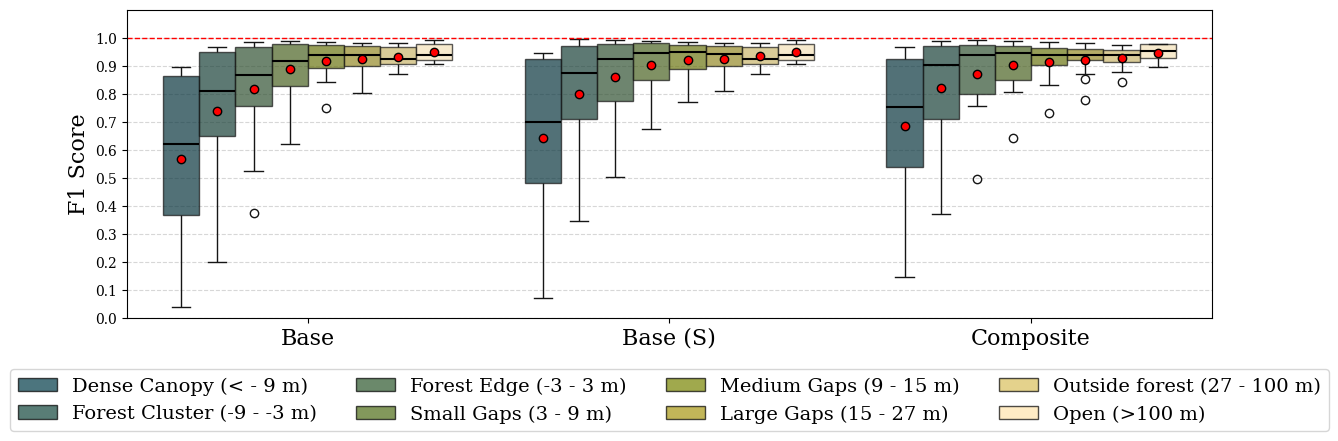

In [9]:
import seaborn as sns
import cmcrameri.cm as cmc
from matplotlib.patches import Patch
plt.rcParams['font.family'] = 'serif'
# set fig size
model_order = ['base', 'baseS', 'composite']
fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(
    x=dce_all['model'],
    y=dce_all['f1'],
    hue=dce_all['code'],
    order = model_order,
    palette=cmc.bamako, showmeans=True,
    meanprops={"marker":"o","markerfacecolor":"red", "markeredgecolor":"black"}, medianprops={"color": "black", "linewidth": 1.5}
)


for patch in ax.patches:
    patch.set_alpha(0.7)
#add horizontal red dashed line
ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
# set y lim
ax.set_ylim(0, 1.1)
ax.set_xlabel('', fontsize=14)
ax.set_xticklabels(['Base', 'Base (S)', 'Composite'], fontsize=16)
ax.set_ylabel('F1 Score', fontsize=16)
colors = [cmc.bamako(i / (len(dce_all['code'].unique()) - 1)) for i in range(len(dce_all['code'].unique()))]
labels = ['Dense Canopy (< - 9 m)', 'Forest Cluster (-9 - -3 m)', 'Forest Edge (-3 - 3 m)', 'Small Gaps (3 - 9 m)', 'Medium Gaps (9 - 15 m)', 'Large Gaps (15 - 27 m)', 'Outside forest (27 - 100 m)', 'Open (>100 m)']
# Create custom legend
custom_legend = [
    Patch(facecolor=colors[i], label=labels[i], alpha=.7,edgecolor='black') for i in range(len(labels))
]
ax.legend(handles=custom_legend, loc='lower center', fontsize=14, ncol = 4, bbox_to_anchor=(0.5, -0.4), frameon=True)



# # Step 1: Get unique model positions
# model_pos = {'base': 0, 'baseS': 1, 'composite': 2}
# codes = dce_all['code'].unique()

# # Step 2: Compute median F1 score of 'base' model for each code
# base_medians = (
#     dce_all[dce_all['model'] == 'base']
#     .groupby('code')['f1']
#     .median()
# )

# # Step 3: Plot horizontal lines at base medians on the other models
# for i, code in enumerate(codes):
#     median_f1 = base_medians.get(code, None)
#     if median_f1 is None:
#         continue

#     # Get the number of hue categories to space correctly
#     n_codes = len(codes)
#     offset = (i - (n_codes - 1) / 2) * 0.1  # adjust spacing for dodge

#     for model in ['baseS', 'composite']:
#         xpos = model_pos[model] + offset
#         ax.hlines(
#             y=median_f1,
#             xmin=xpos - 0.05, xmax=xpos + 0.05,
#             colors='black', linestyles='dotted', linewidth=1.5,
#             zorder=0
#         )

# # add background horizontal lines
# ax.yaxis.grid(True, linestyle='-', alpha=0.7)

# plt.title(
#     'other version: more gridlines',
#     fontsize=18
# )
ax.set_yticks(np.arange(0, 1.1, 0.1))  # or 0.05 for finer grid
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
plt.savefig('/home/etboud/projects/figures/dce_f1_scores_gridlines.png', bbox_inches='tight', dpi=400)

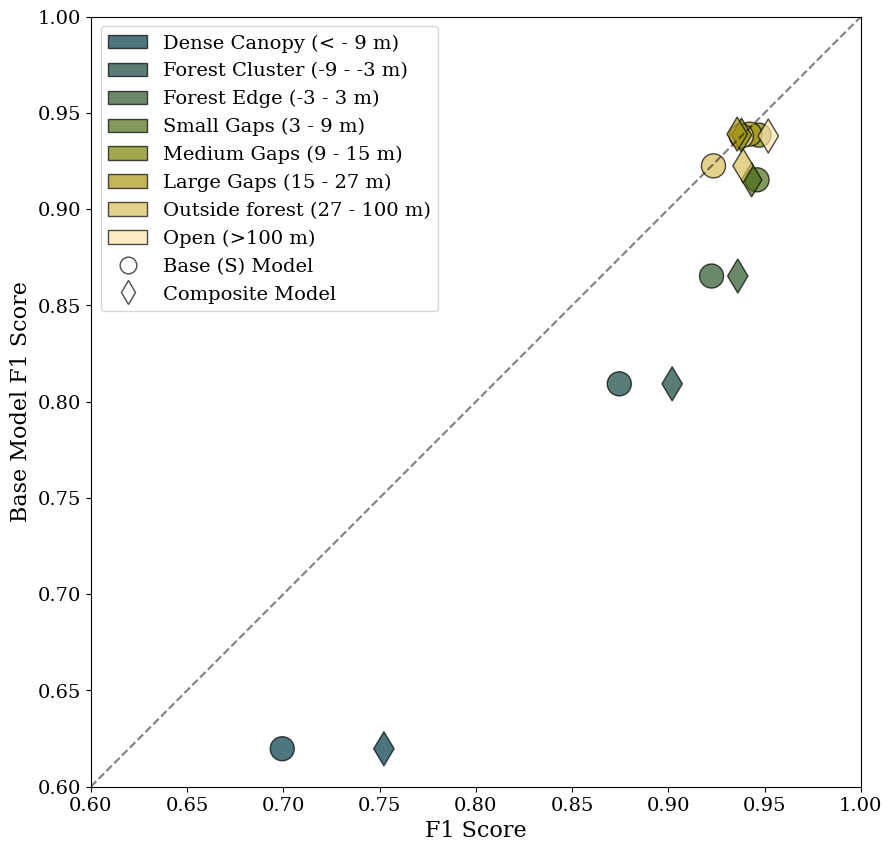

In [111]:
from matplotlib.lines import Line2D
n_code = dce_all[dce_all['model']== 'baseS']['code'].unique()
colors = [cmc.bamako(i / (len(n_code) - 1)) for i in range(len(n_code))]

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(dce_all[dce_all['model']== 'baseS'].groupby('code')['f1'].median(), dce_all[dce_all['model']== 'base'].groupby('code')['f1'].median(), color=colors, s=300, alpha=0.7, edgecolor='black')
ax.scatter(dce_all[dce_all['model']== 'composite'].groupby('code')['f1'].median(), dce_all[dce_all['model']== 'base'].groupby('code')['f1'].median(), color=colors, s=300, alpha=0.7, edgecolor='black', marker='d')
ax.set_xlabel('F1 Score', fontsize=16)
ax.set_ylabel('Base Model F1 Score', fontsize=16)
ax.set_xlim(0.6, 1)
ax.set_ylim(0.6, 1)
# one to one line
ax.plot([0.6, 1], [0.6, 1], color='black', linestyle='--', linewidth=1.5, alpha=.5)
# add legend
custom_legend = [
    Patch(facecolor=colors[i], label=labels[i], alpha=.7, edgecolor='black') for i in range(len(labels))
] + [
    Line2D([0], [0], markeredgecolor='black', label='Base (S) Model', markersize=12, linewidth=1, marker='o', color='white', alpha=.7, linestyle='None'),
    Line2D([0], [0], markeredgecolor='black', label='Composite Model', markersize=12, linewidth=1, marker='d', color='white', alpha=.7, linestyle='None')
]
ax.legend(handles=custom_legend, loc='upper left', fontsize=14, ncol = 1, frameon=True)
plt.gca().set_aspect('equal')


/tmp/ipykernel_1239820/1009254289.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Base', 'Base (S)', 'Composite'], fontsize=10)
/tmp/ipykernel_1239820/1009254289.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


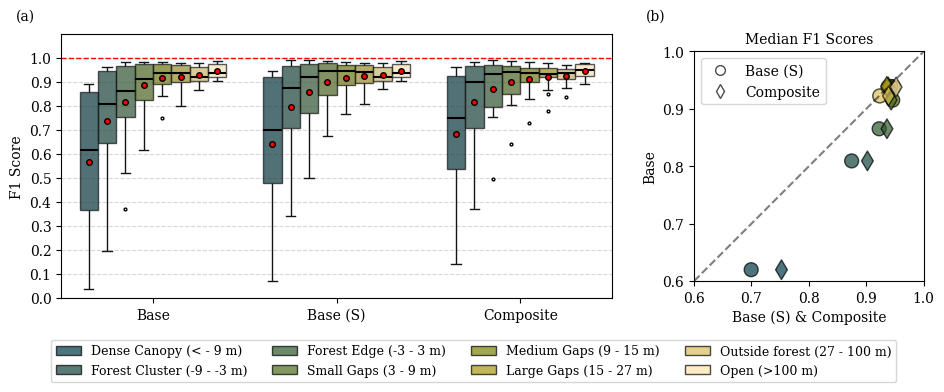

In [13]:

fig = plt.figure(figsize=(7.5, 3))
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'font.size': 10})
# set fig size
model_order = ['base', 'baseS', 'composite']
# Create a 2-row, 5-column grid
gs = fig.add_gridspec(1, 2, width_ratios=[4.8, 2], wspace=0.21, hspace=0.1)

# First subplot: spans both rows in the first column
ax0 = fig.add_subplot(gs[0, 0])  # All rows in column 0
sns.boxplot(
    x=dce_all['model'],
    y=dce_all['f1'],
    hue=dce_all['code'],
    order=model_order,
    palette=cmc.bamako, showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black","markersize":4},
    flierprops={'markerfacecolor': 'white', 'markersize': 2, 'markeredgecolor': 'black'},
    medianprops={"color": "black", "linewidth": 1.5},
    ax=ax0
)


for patch in ax0.patches:
    patch.set_alpha(0.7)
#add horizontal red dashed line
ax0.axhline(y=1, color='red', linestyle='--', linewidth=1)
# set y lim
ax0.set_ylim(0, 1.1)
ax0.set_xlabel('', fontsize=10)
ax0.set_xticklabels(['Base', 'Base (S)', 'Composite'], fontsize=10)
ax0.set_ylabel('F1 Score', fontsize=10)
colors = [cmc.bamako(i / (len(dce_all['code'].unique()) - 1)) for i in range(len(dce_all['code'].unique()))]
labels = ['Dense Canopy (< - 9 m)', 'Forest Cluster (-9 - -3 m)', 'Forest Edge (-3 - 3 m)', 'Small Gaps (3 - 9 m)', 'Medium Gaps (9 - 15 m)', 'Large Gaps (15 - 27 m)', 'Outside forest (27 - 100 m)', 'Open (>100 m)']
ax0.legend_.remove()
ax0.set_yticks(np.arange(0, 1.1, 0.1))  # or 0.05 for finer grid
ax0.yaxis.grid(True, linestyle='--', alpha=0.5)
ax0.tick_params(axis='y', labelsize=10)

ax1 = fig.add_subplot(gs[0, 1], label='ASO Slice')
ax1.scatter(dce_all[dce_all['model']== 'baseS'].groupby('code')['f1'].median(), dce_all[dce_all['model']== 'base'].groupby('code')['f1'].median(), color=colors, s=100, alpha=0.7,edgecolor='black')
ax1.scatter(dce_all[dce_all['model']== 'composite'].groupby('code')['f1'].median(), dce_all[dce_all['model']== 'base'].groupby('code')['f1'].median(), color=colors, s=100, alpha=0.7, marker='d',edgecolor='black')
ax1.set_xlabel('Base (S) & Composite', fontsize=10)
ax1.set_ylabel('Base', fontsize=10)
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim(0.6, 1)
ax1.set_ylim(0.6, 1)
ax1.set_xticks(np.arange(0.6, 1.01, 0.1))  # or 0.05 for finer grid
ax1.set_yticks(np.arange(0.6, 1.01, 0.1))  # or 0.05 for finer grid
ax1.tick_params(axis='x', labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
# one to one line
ax1.plot([0.6, 1], [0.6, 1], color='black', linestyle='--', linewidth=1.5, alpha=.5)
# add legend
custom_legend = [
    Line2D([0], [0], markeredgecolor='black', label='Base (S)', markersize=7, linewidth=1, marker='o', color='white', alpha=.7, linestyle='None'),
    Line2D([0], [0], markeredgecolor='black', label='Composite', markersize=7, linewidth=1, marker='d', color='white', alpha=.7, linestyle='None')
]
ax1.title.set_text('Median F1 Scores')
ax1.title.set_fontsize(10)
ax1.legend(handles=custom_legend, loc='upper left', fontsize=10, ncol = 1, frameon=True)
# Get current position of ax1
pos = ax1.get_position()


# Position legend using figure coordinates (doesn't affect layout)
custom_legend = [
    Patch(facecolor=colors[i], label=labels[i], alpha=.7, edgecolor='black')
    for i in range(len(labels))
]
fig.legend(handles=custom_legend, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=9, frameon=True)

fig.text(-.11, 1.16, '(a)', fontsize=10, ha='left', va='center')
fig.text(.73, 1.16, '(b)', fontsize=10, ha='left', va='center')

# Tighter layout and spacing
fig.tight_layout(pad=0.3)
fig.subplots_adjust(left=-0.05, right=1.1, top=1.1, bottom=0.22, wspace = 0.01)

# plt.savefig('/home/etboud/projects/figures/Figure_3.pdf', bbox_inches='tight', format='pdf')

/tmp/ipykernel_1239820/1139679760.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Base', 'Base (S)', 'Composite'], fontsize=12)
/tmp/ipykernel_1239820/1139679760.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.1)


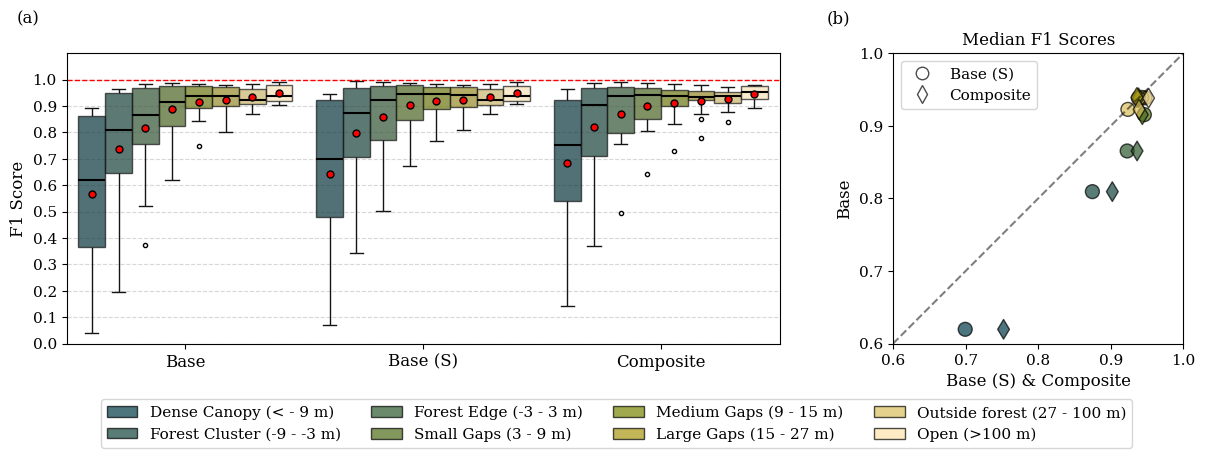

In [57]:

fig = plt.figure(figsize=(10, 3.5))
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'font.size': 11})
# set fig size
model_order = ['base', 'baseS', 'composite']
# Create a 2-row, 5-column grid
gs = fig.add_gridspec(1, 2, width_ratios=[4, 2], wspace=0.15, hspace=0.1)

# First subplot: spans both rows in the first column
ax0 = fig.add_subplot(gs[0, 0])  # All rows in column 0
sns.boxplot(
    x=dce_all['model'],
    y=dce_all['f1'],
    hue=dce_all['code'],
    order=model_order,
    palette=cmc.bamako, showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black","markersize":5},
    flierprops={'markerfacecolor': 'white', 'markersize': 3, 'markeredgecolor': 'black'},
    medianprops={"color": "black", "linewidth": 1.5},
    ax=ax0,
    width = .9
)


for patch in ax0.patches:
    patch.set_alpha(0.7)
#add horizontal red dashed line
ax0.axhline(y=1, color='red', linestyle='--', linewidth=1)
# set y lim
ax0.set_ylim(0, 1.1)
ax0.set_xlabel('', fontsize=11)
ax0.set_xticklabels(['Base', 'Base (S)', 'Composite'], fontsize=12)
ax0.set_ylabel('F1 Score', fontsize=12)
colors = [cmc.bamako(i / (len(dce_all['code'].unique()) - 1)) for i in range(len(dce_all['code'].unique()))]
labels = ['Dense Canopy (< - 9 m)', 'Forest Cluster (-9 - -3 m)', 'Forest Edge (-3 - 3 m)', 'Small Gaps (3 - 9 m)', 'Medium Gaps (9 - 15 m)', 'Large Gaps (15 - 27 m)', 'Outside forest (27 - 100 m)', 'Open (>100 m)']
ax0.legend_.remove()
ax0.set_yticks(np.arange(0, 1.1, 0.1))  # or 0.05 for finer grid
ax0.yaxis.grid(True, linestyle='--', alpha=0.5)
ax0.tick_params(axis='y', labelsize=11)

ax1 = fig.add_subplot(gs[0, 1], label='ASO Slice')
ax1.scatter(dce_all[dce_all['model']== 'baseS'].groupby('code')['f1'].median(), dce_all[dce_all['model']== 'base'].groupby('code')['f1'].median(), color=colors, s=100, alpha=0.7,edgecolor='black')
ax1.scatter(dce_all[dce_all['model']== 'composite'].groupby('code')['f1'].median(), dce_all[dce_all['model']== 'base'].groupby('code')['f1'].median(), color=colors, s=100, alpha=0.7, marker='d',edgecolor='black')
ax1.set_xlabel('Base (S) & Composite', fontsize=12)
ax1.set_ylabel('Base', fontsize=12)
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim(0.6, 1)
ax1.set_ylim(0.6, 1)
ax1.set_xticks(np.arange(0.6, 1.01, 0.1))  # or 0.05 for finer grid
ax1.set_yticks(np.arange(0.6, 1.01, 0.1))  # or 0.05 for finer grid
ax1.tick_params(axis='x', labelsize=11)
ax1.tick_params(axis='y', labelsize=11)
# one to one line
ax1.plot([0.6, 1], [0.6, 1], color='black', linestyle='--', linewidth=1.5, alpha=.5)
# add legend
custom_legend = [
    Line2D([0], [0], markeredgecolor='black', label='Base (S)', markersize=9, linewidth=1, marker='o', color='white', alpha=.7, linestyle='None'),
    Line2D([0], [0], markeredgecolor='black', label='Composite', markersize=9, linewidth=1, marker='d', color='white', alpha=.7, linestyle='None')
]
ax1.title.set_text('Median F1 Scores')
ax1.title.set_fontsize(12)
ax1.legend(handles=custom_legend, loc='upper left', fontsize=11, ncol = 1, frameon=True)
# Get current position of ax1
pos = ax1.get_position()


# Position legend using figure coordinates (doesn't affect layout)
custom_legend = [
    Patch(facecolor=colors[i], label=labels[i], alpha=.7, edgecolor='black')
    for i in range(len(labels))
]
fig.legend(handles=custom_legend, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=11, frameon=True)

fig.text(-.1, 1.15, '(a)', fontsize=12, ha='left', va='center')
fig.text(.71, 1.15, '(b)', fontsize=12, ha='left', va='center')

# Tighter layout and spacing
fig.tight_layout(pad=0.1)
fig.subplots_adjust(left=-.05, right=1.1, top=1.05, bottom=0.22, wspace = 0.3)
# plt.savefig('/home/etboud/projects/figures/Figure_3_resize.pdf', bbox_inches='tight', format='pdf')

/tmp/ipykernel_1221140/2042020657.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Base', 'Base (S)', 'Composite'], fontsize=10)


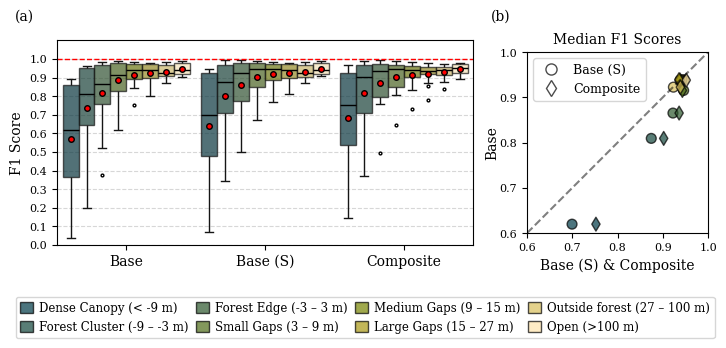

In [181]:
# Set figure width to 7.5 inches (Elsevier standard) and reasonable height
fig = plt.figure(figsize=(7, 3.3))  

# Font configuration
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'font.size': 10})

model_order = ['base', 'baseS', 'composite']

# GridSpec layout with tight spacing
gs = fig.add_gridspec(1, 2, width_ratios=[2.3, 1], wspace=0.18)

# First subplot: Boxplot
ax0 = fig.add_subplot(gs[0, 0])
sns.boxplot(
    x=dce_all['model'],
    y=dce_all['f1'],
    hue=dce_all['code'],
    order=model_order,
    palette=cmc.bamako, showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black","markersize":4},
    medianprops={"color": "black", "linewidth": 1},
    flierprops={'markerfacecolor': 'white', 'markersize': 2, 'markeredgecolor': 'black'},
    ax=ax0,
    width = .92
)

# Styling
for patch in ax0.patches:
    patch.set_alpha(0.7)

ax0.axhline(y=1, color='red', linestyle='--', linewidth=1)
ax0.set_ylim(0, 1.1)
ax0.set_xlabel('')
ax0.set_xticklabels(['Base', 'Base (S)', 'Composite'], fontsize=10)
ax0.set_ylabel('F1 Score', fontsize=10)
ax0.set_yticks(np.arange(0, 1.1, 0.1))
ax0.yaxis.grid(True, linestyle='--', alpha=0.5)
ax0.tick_params(axis='y', labelsize=8)
ax0.legend_.remove()

# Legend colors and labels
colors = [cmc.bamako(i / (len(dce_all['code'].unique()) - 1)) for i in range(len(dce_all['code'].unique()))]
labels = ['Dense Canopy (< -9 m)', 'Forest Cluster (-9 – -3 m)', 'Forest Edge (-3 – 3 m)',
          'Small Gaps (3 – 9 m)', 'Medium Gaps (9 – 15 m)', 'Large Gaps (15 – 27 m)',
          'Outside forest (27 – 100 m)', 'Open (>100 m)']

# Second subplot: Scatter plot
ax1 = fig.add_subplot(gs[0, 1], label='ASO Slice')
ax1.scatter(
    dce_all[dce_all['model'] == 'baseS'].groupby('code')['f1'].median(),
    dce_all[dce_all['model'] == 'base'].groupby('code')['f1'].median(),
    color=colors, s=50, alpha=0.7, edgecolor='black'
)
ax1.scatter(
    dce_all[dce_all['model'] == 'composite'].groupby('code')['f1'].median(),
    dce_all[dce_all['model'] == 'base'].groupby('code')['f1'].median(),
    color=colors, s=50, alpha=0.7, marker='d', edgecolor='black'
)

ax1.set_xlabel('Base (S) & Composite', fontsize=10)
ax1.set_ylabel('Base', fontsize=10, labelpad=0)
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim(0.6, 1)
ax1.set_ylim(0.6, 1)
ax1.set_xticks(np.arange(0.6, 1.01, 0.1))
ax1.set_yticks(np.arange(0.6, 1.01, 0.1))
ax1.tick_params(axis='x', labelsize=8)
ax1.tick_params(axis='y', labelsize=8)
ax1.plot([0.6, 1], [0.6, 1], color='black', linestyle='--', linewidth=1.5, alpha=0.5)

# Custom legend for scatter markers
custom_legend = [
    Line2D([0], [0], marker='o', color='white', markeredgecolor='black',
           markersize=8, label='Base (S)', linestyle='None', alpha=0.7),
    Line2D([0], [0], marker='d', color='white', markeredgecolor='black',
           markersize=8, label='Composite', linestyle='None', alpha=0.7)
]
ax1.set_title('Median F1 Scores', fontsize=10)
ax1.legend(handles=custom_legend, loc='upper left', fontsize=9, frameon=True)

# Panel labels
fig.text(0.0, 0.98, '(a)', fontsize=10)
fig.text(0.68, 0.98, '(b)', fontsize=10)

# Shared color legend at bottom center
color_legend = [
    Patch(facecolor=colors[i], label=labels[i], alpha=0.7, edgecolor='black')
    for i in range(len(labels))
]
fig.legend(handles=color_legend, loc='lower center', bbox_to_anchor=(0.5,0 ),
           ncol=4, fontsize=8.5, frameon=True,columnspacing=0.6,handletextpad=0.53, handlelength=1.1,handleheight=1.1)

# Final tight layout with correct margins (keep everything within 7.5 x 3 inches)
fig.subplots_adjust(left=0.06, right=.99, top=0.92, bottom=0.3, wspace=0.05)
# plt.tight_layout(pad=0)
plt.savefig('/home/etboud/projects/figures/Figure_3_test.pdf', bbox_inches='tight', format='pdf')
# 


#### DCE Map

In [ ]:
# plot dce_mask with cmc.bamako colormap
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams['font.family'] = 'serif'


# categorical colorbar
from matplotlib import cm
from matplotlib.colors import ListedColormap

colors = [cmc.bamako(i / (len(dce_all['code'].unique()) - 1)) for i in range(len(dce_all['code'].unique()))]
labels = ['Dense Canopy', 'Forest Cluster', 'Forest Edge', 'Small Gaps', 'Medium Gaps', 'Large Gaps', 'Outside forest', 'Open']
cmap = ListedColormap(colors)
im = plt.imshow(dce_mask.values[0], alpha=.9,cmap=cmap, vmin=-1, vmax=6)

# cbar = fig.colorbar(im, ax=ax, pad=0.01,alpha = .9)
# cbar.ax.set_yticklabels(labels, fontsize =16)

plt.title('DCE Categories', fontstyle='normal', fontsize=16)
plt.xticks([])
plt.yticks([])
plt.savefig('/home/etboud/projects/figures/dce_mask_title_no_label.png', bbox_inches='tight', dpi=400)

### Difference Maps

In [3]:
def calc_false_color(ds):
    # Selecting RGB bands
    blue_band = ds.isel(band=0)
    green_band = ds.isel(band=1)
    red_band = ds.isel(band=2)
    nir_band = ds.isel(band=3)
    
    # normalize
    maxval = green_band.max().values
    minval = green_band.min().values
    red_norm = (red_band - minval) / (maxval - minval)
    green_norm = (green_band - minval) / (maxval - minval)
    blue_norm = (blue_band - minval) / (maxval - minval)
    nir_norm = (nir_band - minval) / (maxval - minval)
    green_norm = green_norm.where(red_norm <= 1,1)
    blue_norm = blue_norm.where(red_norm <= 1,1)
    red_norm = red_norm.where(red_norm <= 1,1)
    nir_norm = nir_norm.where(red_norm <= 1,1)

    red_band = red_band.values
    green_band = green_band.values
    blue_band = blue_band.values
    nir_band = nir_band.values
    
    # Stack normalized bands to create RGB image
    false_image = np.stack([nir_norm, red_norm, green_norm], axis=-1)
    return red_band,green_band,blue_band,nir_band,false_image 

# calculate the rgb bands and normalize radiances
# see 1_classify_train_model.ipynb
def calc_rgb(ds):
    # Selecting RGB bands
    blue_band = ds.isel(band=0)
    green_band = ds.isel(band=1)
    red_band = ds.isel(band=2)
    nir_band = ds.isel(band=3)
    
    # normalize
    maxval = green_band.max().values
    minval = green_band.min().values
    red_norm = (red_band - minval) / (maxval - minval)
    green_norm = (green_band - minval) / (maxval - minval)
    blue_norm = (blue_band - minval) / (maxval - minval)
    green_norm = green_norm.where(red_norm <= 1,1)
    blue_norm = blue_norm.where(red_norm <= 1,1)
    red_norm = red_norm.where(red_norm <= 1,1)

    red_band = red_band.values
    green_band = green_band.values
    blue_band = blue_band.values
    nir_band = nir_band.values
    
    # Stack normalized bands to create RGB image
    rgb_image = np.stack([red_norm, green_norm, blue_norm], axis=-1)
    return red_band,green_band,blue_band,nir_band,rgb_image

In [4]:

name = 'BUDD'
year = '2022'
month = '04'
ps_day = '30'
aso_day = '29'
index = 2

ps_time = f'{year}-{month}-{ps_day}T00:00:00.000000000'
aso_time = f'{year}-{month}-{aso_day}T00:00:00.000000000'
str_time = f'{year}{month}{ps_day}'  # e.g., for April 30, 2022


data_direc = f'/data0/images/planet/emma/planet/{name}/'
fn = f'/home/etboud/projects/data/stacks/sep/{name}_base_{year}_projected.nc'
pp_fn = f'/home/etboud/projects/data/stacks/sep/{name}_baseS_{year}_3_30.nc'
comp_fn = f'/home/etboud/projects/data/stacks/sep/{name}_composite_{year}_projected.nc'



ps = xr.open_dataset(fn)
pp = xr.open_dataset(pp_fn)
comp = xr.open_dataset(comp_fn)
# Get all subdirectories for that year
subdirecs = sorted([d for d in glob.glob(os.path.join(data_direc, year + '*')) if os.path.isdir(d)])



# Filter subdirectories that match the desired date
matching_dirs = [d for d in subdirecs if str_time in d]

# DEBUG: print all found scenes for the date
print("Scenes found:")
for i, d in enumerate(matching_dirs):
    print(f"[{i}] {d}")

# Safely select the second one (index = 1)
if len(matching_dirs) > 1:
    selected_dir = matching_dirs[index]  # Select second
    print(f"Selected scene: {selected_dir}")
    
    # Get the SR_clip.tif file (assuming one per subdir)
    tif_files = glob.glob(os.path.join(selected_dir, '*', 'PSScene', '*SR_clip.tif'))
    if tif_files:
        fname = tif_files[0]
        code = selected_dir.split('/')[-1]
        
        # Load and clip
        image = rxr.open_rasterio(fname).rio.clip(basin.geometry, drop=True, all_touched=True)
        
        # Process image
        _, _, _, _, false_image = calc_false_color(image)
        _, _, _, _, rgb_image = calc_rgb(image)
    else:
        print("No SR_clip.tif found in selected scene.")
else:
    print("Less than 2 matching scenes found.")

model_slice = ps['data'].sel(time=ps_time)
model_slice_pp = pp['data'].sel(time=ps_time)     
aso_slice = aso['data'].sel(time=aso_time)
comp_slice = comp['data'].sel(time=ps_time)

if len(model_slice.shape) == 3:
    model_slice = model_slice[1]
    model_slice_pp = model_slice_pp[1]
    comp_slice = comp_slice[1]

Scenes found:
[0] /data0/images/planet/emma/planet/BUDD/20220430_181847_93_249d
[1] /data0/images/planet/emma/planet/BUDD/20220430_181850_23_249d
[2] /data0/images/planet/emma/planet/BUDD/20220430_181902_39_2482
[3] /data0/images/planet/emma/planet/BUDD/20220430_181904_67_2482
Selected scene: /data0/images/planet/emma/planet/BUDD/20220430_181902_39_2482


In [11]:
#this should work
name = 'BUDD'
year = '2023'
month = '06'
ps_day = '01'
aso_day = '01'
index = 0

ps_time = f'{year}-{month}-{ps_day}T00:00:00.000000000'
aso_time = f'{year}-{month}-{aso_day}T00:00:00.000000000'
str_time = f'{year}{month}{ps_day}'  # e.g., for April 30, 2022


data_direc = f'/data0/images/planet/emma/planet/{name}/'
fn = f'/home/etboud/projects/data/stacks/sep/{name}_base_{year}_projected.nc'
pp_fn = f'/home/etboud/projects/data/stacks/sep/{name}_baseS_{year}_3_30.nc'
comp_fn = f'/home/etboud/projects/data/stacks/sep/{name}_composite_{year}_projected.nc'



ps = xr.open_dataset(fn)
pp = xr.open_dataset(pp_fn)
comp = xr.open_dataset(comp_fn)
# Get all subdirectories for that year
subdirecs = sorted([d for d in glob.glob(os.path.join(data_direc, year + '*')) if os.path.isdir(d)])



# Filter subdirectories that match the desired date
matching_dirs = [d for d in subdirecs if str_time in d]

# DEBUG: print all found scenes for the date
print("Scenes found:")
for i, d in enumerate(matching_dirs):
    print(f"[{i}] {d}")

# Safely select the second one (index = 1)
if len(matching_dirs) > 1:
    selected_dir = matching_dirs[index]  # Select second
    print(f"Selected scene: {selected_dir}")
    
    # Get the SR_clip.tif file (assuming one per subdir)
    tif_files = glob.glob(os.path.join(selected_dir, '*', 'PSScene', '*SR_clip.tif'))
    if tif_files:
        fname = tif_files[0]
        code = selected_dir.split('/')[-1]
        
        # Load and clip
        image = rxr.open_rasterio(fname).rio.clip(basin.geometry, drop=True, all_touched=True)
        
        # Process image
        _, _, _, _, false_image = calc_false_color(image)
        _, _, _, _, rgb_image = calc_rgb(image)
    else:
        print("No SR_clip.tif found in selected scene.")
else:
    print("Less than 2 matching scenes found.")

model_slice = ps['data'].sel(time=ps_time)
model_slice_pp = pp['data'].sel(time=ps_time)     
aso_slice = aso['data'].sel(time=aso_time)
comp_slice = comp['data'].sel(time=ps_time)

if len(model_slice.shape) == 3:
    model_slice = model_slice[index]
    model_slice_pp = model_slice_pp[index]
    comp_slice = comp_slice[index]


Scenes found:
[0] /data0/images/planet/emma/planet/BUDD/20230601_175109_84_24c8
[1] /data0/images/planet/emma/planet/BUDD/20230601_175112_16_24c8
Selected scene: /data0/images/planet/emma/planet/BUDD/20230601_175109_84_24c8


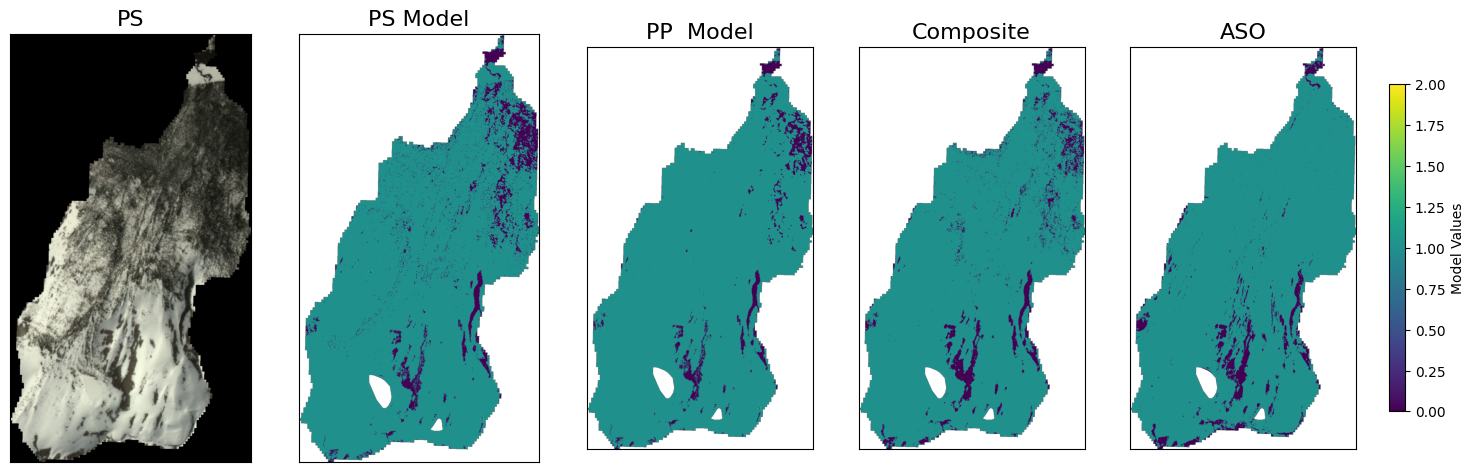

In [12]:
fig, axs = plt.subplots(1, 5, figsize=(18, 10))
axs = axs.flatten()

# Define common vmin and vmax
vmin = min(model_slice.min(), model_slice_pp.min(), aso_slice.min())
vmax = max(model_slice.max(), model_slice_pp.max(), aso_slice.max())

# Plot RGB and false color (no vmin/vmax needed)
axs[0].imshow(rgb_image)
axs[0].set_title(f'PS', fontsize=16)


# Model slices with shared color scale
im0 = axs[1].imshow(model_slice, vmin=vmin, vmax=vmax, cmap='viridis')
axs[1].set_title(f'PS Model', fontsize=16)



im1 = axs[2].imshow(model_slice_pp, vmin=vmin, vmax=vmax, cmap='viridis')
axs[2].set_title(f'PP  Model', fontsize=16)
im2 = axs[3].imshow(comp_slice, vmin=vmin, vmax=vmax, cmap='viridis')
axs[3].set_title(f'Composite', fontsize=16)
im3 = axs[4].imshow(aso_slice, vmin=vmin, vmax=vmax, cmap='viridis')
axs[4].set_title(f'ASO', fontsize=16)


# Add one shared colorbar
cbar = fig.colorbar(im2, ax=[axs[2], axs[3], axs[4]], orientation='vertical',
                    fraction=0.02, pad=0.04, label='Model Values')

# Cleanup axes
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.grid(False)

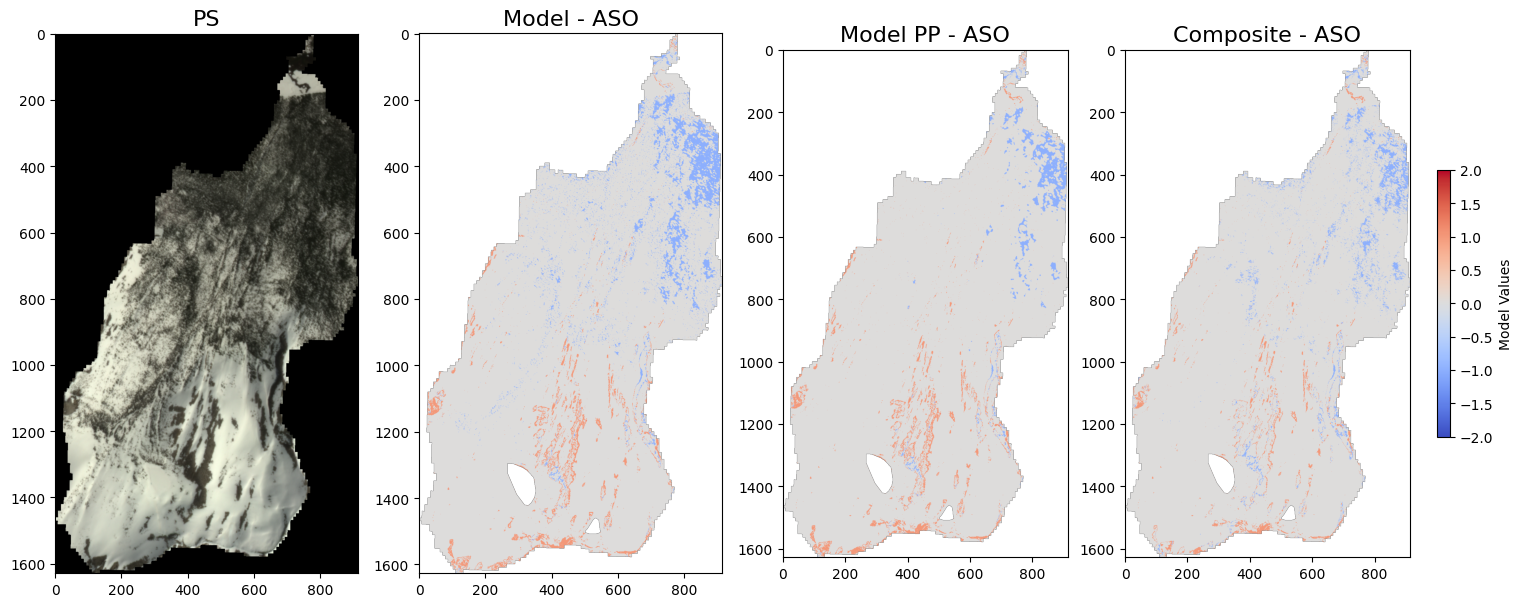

In [7]:
model_diff = model_slice - aso_slice
model_diff_pp = model_slice_pp - aso_slice
model_diff_comp = comp_slice - aso_slice
fig, axs = plt.subplots(1, 4, figsize=(18, 10))
axs = axs.flatten()
# Plot the differences
axs[0].imshow(rgb_image)
axs[0].set_title(f'PS', fontsize=16)
im1 = axs[1].imshow(model_diff, vmin=-vmax, vmax=vmax, cmap='coolwarm')
axs[1].set_title(f'Model - ASO', fontsize=16)
axs[2].imshow(model_diff_pp, vmin=-vmax, vmax=vmax, cmap='coolwarm')
axs[2].set_title(f'Model PP - ASO', fontsize=16)
axs[3].imshow(model_diff_comp, vmin=-vmax, vmax=vmax, cmap='coolwarm')
axs[3].set_title(f'Composite - ASO', fontsize=16)

# Add one shared colorbar
cbar = fig.colorbar(im1, ax=[axs[2], axs[3]], orientation='vertical',
                    fraction=0.02, pad=0.04, label='Model Values')



In [9]:
false_image = np.where(false_image == 0, np.nan, false_image)

model_slice = ma.masked_where(model_slice == 0, model_slice)
model_slice_pp = ma.masked_where(model_slice_pp == 0, model_slice_pp)
comp_slice = ma.masked_where(comp_slice == 0, comp_slice)
aso_slice = ma.masked_where(aso_slice == 0, aso_slice)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07227032227032228..1.0045695045695047].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07227032227032228..1.0045695045695047].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07227032227032228..1.0045695045695047].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07227032227032228..1.0045695045695047].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07227032227032228..1.0045695045695047].


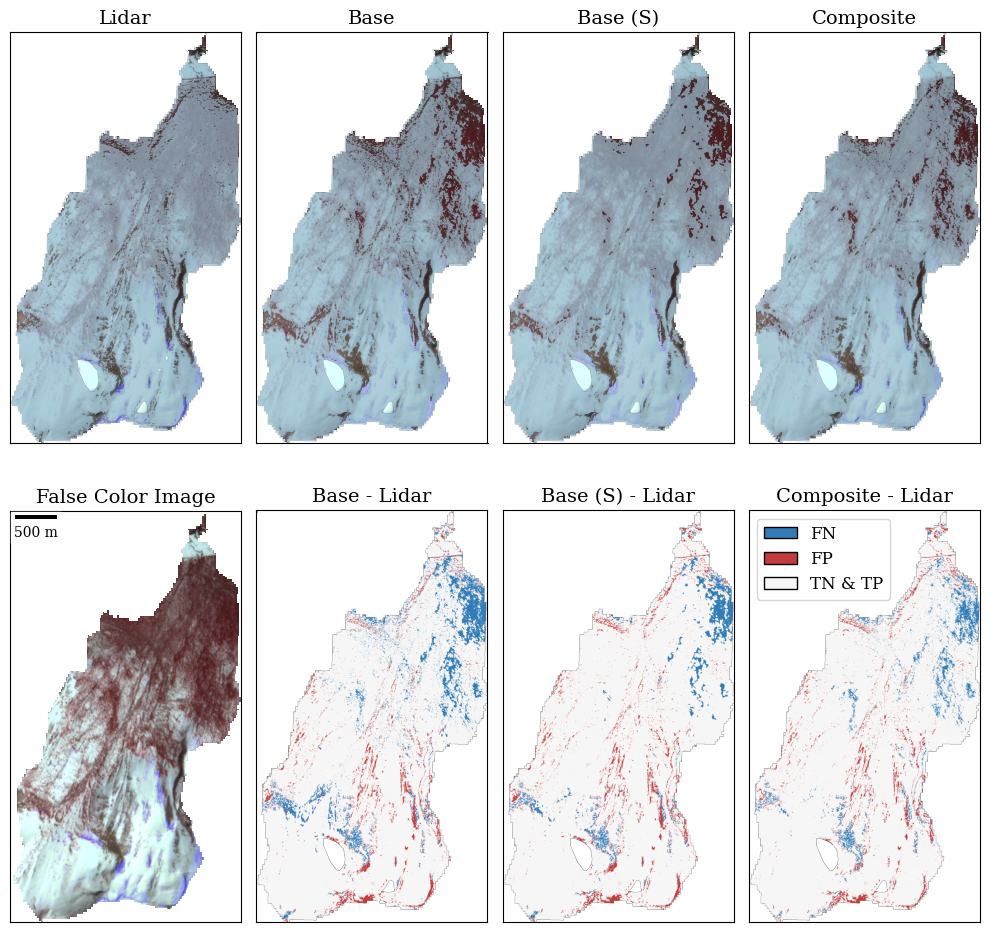

In [32]:

listed_cmap = 'cmc.glasgow'
listed_cmap_diff = 'RdBu_r'
import matplotlib.colors as mcolors

# Set number of discrete bins
n_bins = 3  # You can choose 4, 6, 8, etc.
false_cmap = plt.cm.gray
false_cmap.set_bad(color='white')
base_cmap = plt.get_cmap(listed_cmap)
listed_cmap = mcolors.ListedColormap(base_cmap(np.linspace(.7, 1, n_bins)))
listed_cmap.set_bad(color='none')
base_cmap_diff = plt.get_cmap(listed_cmap_diff)
listed_cmap_diff = mcolors.ListedColormap(base_cmap_diff(np.linspace(0.15, .85, n_bins)))



fig = plt.figure(figsize=(10, 10))
plt.rcParams['font.family'] = 'serif'


# Create a 2-row, 5-column grid
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1], width_ratios=[ 1, 1, 1, 1])



ax1 = fig.add_subplot(gs[0, 0], label='ASO Slice')
ax1.imshow(false_image, cmap=false_cmap)
ax1.imshow(aso_slice, cmap=listed_cmap, alpha = 0.7, vmin=vmin, vmax=vmax,)
ax2 = fig.add_subplot(gs[1, 0], label='False Color Image')
ax2.imshow(false_image, cmap='gray')
# Next 6 subplots (2 rows × 3 columns) in columns 1, 2, 3
ax3 = fig.add_subplot(gs[0, 1],label='Base')
ax3.imshow(false_image, cmap='gray')
ax3.imshow(model_slice, cmap=listed_cmap, alpha=0.7, vmin=vmin, vmax=vmax,)
ax4 = fig.add_subplot(gs[0, 2], label='Base (S)')
ax4.imshow(false_image, cmap='gray')
ax4.imshow(model_slice_pp, cmap=listed_cmap, alpha=0.7, vmin=vmin, vmax=vmax,)
ax5 = fig.add_subplot(gs[0, 3], label='Composite')
ax5.imshow(false_image, cmap='gray')
ax5.imshow(comp_slice, cmap=listed_cmap, alpha=0.7, vmin=vmin, vmax=vmax,)
ax6 = fig.add_subplot(gs[1, 1], label='Base - ASO')
ax6.imshow(model_diff, cmap=listed_cmap_diff, vmin=-vmax, vmax=vmax,)
ax7 = fig.add_subplot(gs[1, 2], label='Base (S) - ASO')
ax7.imshow(model_diff_pp, cmap=listed_cmap_diff, vmin=-vmax, vmax=vmax,)
ax8 = fig.add_subplot(gs[1, 3], label='Composite - ASO')
ax8.imshow(model_diff_comp, cmap=listed_cmap_diff, vmin=-vmax, vmax=vmax,)



# add scalebar
from matplotlib_scalebar.scalebar import ScaleBar
scalebar1 = ScaleBar(dx=3, units='m', location='upper left', scale_loc='bottom', font_properties={'family': 'serif'})

ax2.add_artist(scalebar1)
titles = [
        'Lidar','False Color Image',
        'Base','Base (S)',
        'Composite','Base - Lidar',
        'Base (S) - Lidar','Composite - Lidar']
for i, (ax, title) in enumerate(zip([ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8], titles)):
    ax.set_title(title, fontsize=14, fontname='serif')
    ax.plot([0, 1], [0, i])  # Example plot
    ax.set_xticks([])
    ax.set_yticks([])
    

    
plt.tight_layout()


# # Regular data colormap (viridis)
# cb1 = fig.colorbar(
#     ax3.images[-1],  # The model_slice overlay
#     ax=[ax1, ax3, ax4, ax5],
#     orientation='vertical',
#     fraction=0.02, pad=0.02,
#     label='Model Value',
#     shrink=0.9
# )

# # Difference map colormap (coolwarm)
# cb2 = fig.colorbar(
#     ax6.images[-1],  # The model_diff overlay
#     ax=[ax6, ax7, ax8],
#     orientation='vertical',
#     fraction=0.02, pad=0.02,
#     label='Model - ASO',
#     shrink=0.9
# )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=listed_cmap_diff(0.2), edgecolor='black', label='FN'),
    Patch(facecolor=listed_cmap_diff(0.8), edgecolor='black', label='FP'),
    Patch(facecolor=listed_cmap_diff(0.5), edgecolor='black', label='TN & TP'),
]
ax8.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True)
plt.savefig('/home/etboud/projects/figures/basin_map_comparison_20220430_181902_39_2482.png', bbox_inches='tight', dpi=400)


/tmp/ipykernel_1230177/2704298981.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


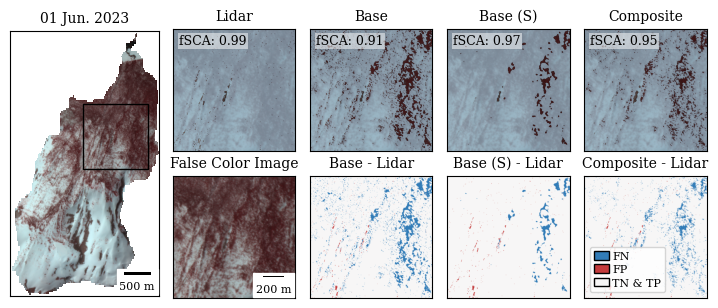

In [43]:

listed_cmap = 'cmc.glasgow'
listed_cmap_diff = 'RdBu_r'
import matplotlib.colors as mcolors

# Set number of discrete bins
n_bins = 3  # You can choose 4, 6, 8, etc.
false_cmap = plt.cm.gray
false_cmap.set_bad(color='white')
base_cmap = plt.get_cmap(listed_cmap)
listed_cmap = mcolors.ListedColormap(base_cmap(np.linspace(.7, 1, n_bins)))
listed_cmap.set_bad(color='none')
base_cmap_diff = plt.get_cmap(listed_cmap_diff)
listed_cmap_diff = mcolors.ListedColormap(base_cmap_diff(np.linspace(0.15, .85, n_bins)))



fig = plt.figure(figsize=(9, 3.5))
plt.rcParams['font.family'] = 'serif'


# Create a 2-row, 5-column grid
gs = fig.add_gridspec(2, 5, height_ratios=[1, 1], width_ratios=[1.2, 1, 1, 1, 1],wspace=0.1)

# First subplot: spans both rows in the first column
ax0 = fig.add_subplot(gs[:, 0])  # All rows in column 0
ax0.imshow(false_image, cmap='gray')


ax1 = fig.add_subplot(gs[0, 1], label='ASO Slice')
ax1.imshow(false_image, cmap=false_cmap)
ax1.imshow(aso_slice, cmap=listed_cmap, alpha = 0.7, vmin=vmin, vmax=vmax,)
ax2 = fig.add_subplot(gs[1, 1], label='False Color Image')
ax2.imshow(false_image, cmap='gray')
# Next 6 subplots (2 rows × 3 columns) in columns 1, 2, 3
ax3 = fig.add_subplot(gs[0, 2],label='Base')
ax3.imshow(false_image, cmap='gray')
ax3.imshow(model_slice, cmap=listed_cmap, alpha=0.7, vmin=vmin, vmax=vmax,)
ax4 = fig.add_subplot(gs[0, 3], label='Base (S)')
ax4.imshow(false_image, cmap='gray')
ax4.imshow(model_slice_pp, cmap=listed_cmap, alpha=0.7, vmin=vmin, vmax=vmax,)
ax5 = fig.add_subplot(gs[0, 4], label='Composite')
ax5.imshow(false_image, cmap='gray')
ax5.imshow(comp_slice, cmap=listed_cmap, alpha=0.7, vmin=vmin, vmax=vmax,)
ax6 = fig.add_subplot(gs[1, 2], label='Base - ASO')
ax6.imshow(model_diff, cmap=listed_cmap_diff, vmin=-vmax, vmax=vmax,)
ax7 = fig.add_subplot(gs[1, 3], label='Base (S) - ASO')
ax7.imshow(model_diff_pp, cmap=listed_cmap_diff, vmin=-vmax, vmax=vmax,)
ax8 = fig.add_subplot(gs[1, 4], label='Composite - ASO')
ax8.imshow(model_diff_comp, cmap=listed_cmap_diff, vmin=-vmax, vmax=vmax,)


#add box in ax0
from matplotlib.patches import Rectangle
rect = Rectangle((450, 450), 400, 400, linewidth=1, edgecolor='black', facecolor='none')
ax0.add_patch(rect)
# add scalebar
from matplotlib_scalebar.scalebar import ScaleBar
scalebar = ScaleBar(dx=3, units='m', location='lower right', scale_loc='bottom', font_properties={'family': 'serif', 'size': 8})
scalebar1 = ScaleBar(dx=3, units='m', location='lower right', scale_loc='bottom', font_properties={'family': 'serif', 'size': 8})
ax0.add_artist(scalebar)
ax2.add_artist(scalebar1)
titles = [f'',
        'Lidar','False Color Image',
        'Base','Base (S)',
        'Composite','Base - Lidar',
        'Base (S) - Lidar','Composite - Lidar']
for i, (ax, title) in enumerate(zip([ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8], titles)):
    ax.set_title(title, fontsize=10, fontname='serif')
    ax.plot([0, 1], [0, i])  # Example plot
    ax.set_xticks([])
    ax.set_yticks([])
    
for ax in [ax1, ax2, ax3, ax4, ax5, ax6,ax7,ax8]:
    ax.set_xlim(450, 850)
    ax.set_ylim(850,450)
    
plt.tight_layout()
ax0.title.set_text(f'01 Jun. 2023')

# # Regular data colormap (viridis)
# cb1 = fig.colorbar(
#     ax3.images[-1],  # The model_slice overlay
#     ax=[ax1, ax3, ax4, ax5],
#     orientation='vertical',
#     fraction=0.02, pad=0.02,
#     label='Model Value',
#     shrink=0.9
# )

# # Difference map colormap (coolwarm)
# cb2 = fig.colorbar(
#     ax6.images[-1],  # The model_diff overlay
#     ax=[ax6, ax7, ax8],
#     orientation='vertical',
#     fraction=0.02, pad=0.02,
#     label='Model - ASO',
#     shrink=0.9
# )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=listed_cmap_diff(0.2), edgecolor='black', label='FN'),
    Patch(facecolor=listed_cmap_diff(0.8), edgecolor='black', label='FP'),
    Patch(facecolor=listed_cmap_diff(0.5), edgecolor='black', label='TN & TP'),
]
ax8.legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=8,
    frameon=True,
    handlelength=1.3,    # Shrinks patch width
    handleheight=0.8,    # Shrinks patch height
    handletextpad=0.3,   # Space between patch and label
    borderpad=0.4,       # Space between legend content and border
    labelspacing=0.3     # Vertical space between legend entries
)


# add text to ax2, ax3, ax4, ax5
# ax0.text(0.1, 0.95, '01 Jun. 2023', transform=ax0.transAxes, ha='left', va='top', fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
ax1.text(0.05, 0.95, 'fSCA: 0.99', transform=ax1.transAxes, ha='left', va='top', fontsize=9, color='black', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none',pad=1))
ax3.text(0.05, 0.95, 'fSCA: 0.91', transform=ax3.transAxes, ha='left', va='top', fontsize=9, color='black', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none',pad=1))
ax4.text(0.05, 0.95, 'fSCA: 0.97', transform=ax4.transAxes, ha='left', va='top', fontsize=9, color='black', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none',pad =1))
ax5.text(0.05, 0.95, 'fSCA: 0.95', transform=ax5.transAxes, ha='left', va='top', fontsize=9, color='black', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad = 1))
plt.savefig(f'/home/etboud/projects/figures/Figure_4.png', bbox_inches='tight', dpi=600)
# plt.savefig(f'/home/etboud/projects/figures/Figure_4.pdf', bbox_inches='tight', format='pdf')


In [89]:


datasets = [ps, pp, comp, aso]
names = ['ps', 'pp', 'comp', 'aso']  # If you want to track dataset names

for name, ds in zip(names, datasets):
    # Select a time slice first (e.g., time index 0)
    time_slice = ds.sel(time=ps_time)

    # Now spatially subset using pixel indices for y and x
    # For example, take y pixels 400 to 800, x pixels 200 to 600
    subset = time_slice.isel(
        y=slice(450, 850),
        x=slice(450, 850)
    )


    print(np.unique(subset['data'].values))

    data_vals = subset['data'].values

    snow = np.nansum(data_vals == 1)
    nosnow = np.nansum(data_vals == 0)
    unobs = np.nansum(data_vals == 2)

    fsca = snow / (snow + nosnow + unobs) if (snow + nosnow + unobs) > 0 else np.nan

    print({'name':name,'snow': snow, 'nosnow': nosnow, 'unobs': unobs, 'fsca': round(fsca, 3)})

[0. 1. 2.]
{'name': 'ps', 'snow': 146150, 'nosnow': 13846, 'unobs': 4, 'fsca': 0.913}
[0. 1. 2.]
{'name': 'pp', 'snow': 155804, 'nosnow': 4192, 'unobs': 4, 'fsca': 0.974}
[0. 1.]
{'name': 'comp', 'snow': 152479, 'nosnow': 7521, 'unobs': 0, 'fsca': 0.953}
[0. 1.]
{'name': 'aso', 'snow': 159045, 'nosnow': 955, 'unobs': 0, 'fsca': 0.994}


### RGB Map 

In [ ]:

data_direc = f'/data0/images/planet/emma/planet/BUDD/'
subdirecs = sorted([d for d in glob.glob(data_direc + str(year) + '*') if os.path.isdir(d)])
for dCount,direcc in enumerate(subdirecs):
    if '20230829' in direcc:
        fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
        code = direcc.split('/')[-1]
        image = rxr.open_rasterio(fname).rio.clip(basin.geometry, drop=True, all_touched=True)
        _,_,_,_,rgb_image = calc_rgb(image)
        rgb_image = np.where(rgb_image == 0, np.nan, rgb_image)
        #plot 
        fig, ax = plt.subplots(figsize=(10, 10))
        plt.rcParams['font.family'] = 'serif'
        ax.imshow(rgb_image, cmap='gray')
        #set background color to white
        ax.set_facecolor('white')
        ax.set_xticks([])
        ax.set_yticks([])
        # box thicker
        ax.spines['top'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
        

        
    
        ax.set_title(f"", fontsize=16)
        # add text inside 
        ax.text(0.31, 0.95, f"(b) 29 Aug. 2023", fontsize=20, color='black', ha='center', va='center', transform=ax.transAxes)
        
        #save figure
        plt.savefig(f'/home/etboud/projects/figures/BUDD_{year}_{code}_rgb_box.png', bbox_inches='tight', dpi=400)

### Reflectance Value Density plot

In [3]:
can_snow = pd.read_csv('/home/etboud/projects/data/training_data/self_classified_2022_class1_canopy_composite.csv')
open_snow = pd.read_csv('/home/etboud/projects/data/training_data/self_classified_2022_class1_open_composite.csv')
can_nosnow =pd.read_csv('/home/etboud/projects/data/training_data/self_classified_2022_class0_canopy_composite.csv')
open_nosnow =pd.read_csv('/home/etboud/projects/data/training_data/self_classified_2022_class0_open_composite.csv')

can_snow['label']=1
open_snow['label']=1
can_nosnow['label']=0
open_nosnow['label']=0

canopy_df = pd.concat([can_snow, can_nosnow], ignore_index=True)
open_df = pd.concat([open_snow, open_nosnow], ignore_index=True)

canopy_df['r_scale'] = canopy_df['r'] / 10000
canopy_df['g_scale'] = canopy_df['g'] / 10000
canopy_df['b_scale'] = canopy_df['b'] / 10000
canopy_df['nir_scale'] = canopy_df['nir'] / 10000
open_df['r_scale'] = open_df['r'] / 10000
open_df['g_scale'] = open_df['g'] / 10000
open_df['b_scale'] = open_df['b'] / 10000
open_df['nir_scale'] = open_df['nir'] / 10000

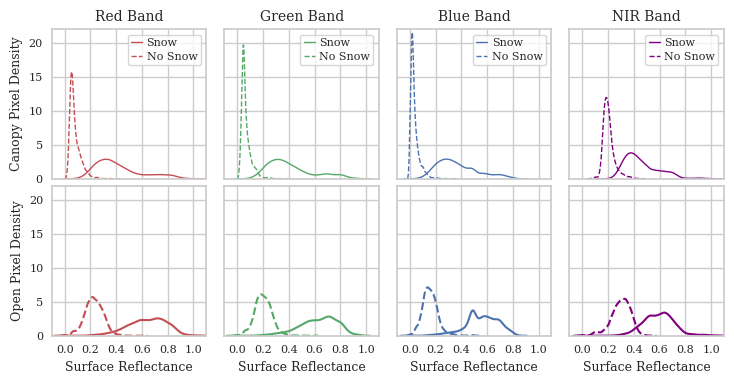

In [6]:
from matplotlib import rcParams
import matplotlib.ticker as ticker
sns.set(style="whitegrid")

bands = ['r_scale', 'g_scale', 'b_scale', 'nir_scale']
colors = ['r', 'g', 'b', 'purple']
titles = ['Red Band', 'Green Band', 'Blue Band', 'NIR Band']

fig, axes = plt.subplots(2, 4, figsize=(7.5, 4), sharex=True, sharey='row')

for i, (band, color, title) in enumerate(zip(bands, colors, titles)):
    rcParams['font.family'] = 'serif'
    # Top row: Canopy
    ax_top = axes[0, i]
    sns.kdeplot(data=canopy_df[canopy_df['label'] == 1], x=band, color=color, linestyle='-', ax=ax_top, label='Snow',lw=1)
    sns.kdeplot(data=canopy_df[canopy_df['label'] == 0], x=band, color=color, linestyle='--', ax=ax_top, label='No Snow',lw=1)
    ax_top.set_xlim(-.1, 1.1)
    ax_top.set_ylim(0, 22)
    ax_top.set_title(title,fontsize=10, fontname='serif')
    if i == 0:
        ax_top.set_ylabel('Canopy Pixel Density', fontsize=9, fontname='serif')
        ax_top.tick_params(axis='y', labelsize=8, pad=.5, labelfontfamily='serif')
    else:
        ax_top.set_ylabel('')
    ax_top.legend(
        loc='upper right',
        fontsize=8,
        frameon=True,
        handlelength=1,
        handletextpad=0.4,
        borderpad=0.3,
        labelspacing=0.3
    )
    ax_top.grid(True,)
    


    # Bottom row: Open
    ax_bottom = axes[1, i]
    sns.kdeplot(data=open_df[open_df['label'] == 1], x=band, color=color, linestyle='-', ax=ax_bottom, label='Snow')
    sns.kdeplot(data=open_df[open_df['label'] == 0], x=band, color=color, linestyle='--', ax=ax_bottom, label='No Snow')
    ax_bottom.set_xlim(-.1, 1.1)
    ax_bottom.set_ylim(0, 22)
    if i == 0:
        ax_bottom.set_ylabel('Open Pixel Density', fontsize=9, fontname='serif')
        ax_bottom.tick_params(axis='y', labelsize=8, pad=0, labelfontfamily='serif')
    else:
        ax_bottom.set_ylabel('')
    ax_bottom.grid(True)
    ax_bottom.set_xlabel('Surface Reflectance',  fontsize=9, fontname='serif')

    ax_bottom.tick_params(axis='x', labelsize=8, pad=1, labelfontfamily='serif')

# After your sns.kdeplot() calls
ax_top.set_xlim(-0.1, 1.1)
ax_top.xaxis.set_major_locator(ticker.MultipleLocator(0.2))  # ← more gridlines
ax_top.grid(True)

ax_bottom.set_xlim(-0.1, 1.1)
ax_bottom.xaxis.set_major_locator(ticker.MultipleLocator(0.2))  # ← more gridlines
ax_bottom.grid(True)    


plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
# plt.savefig('/home/etboud/projects/figures/BUDD_2022_reflectance_kde.png', bbox_inches='tight', dpi=400)
plt.savefig('/home/etboud/projects/figures/Figure_7.pdf', bbox_inches='tight', format='pdf')

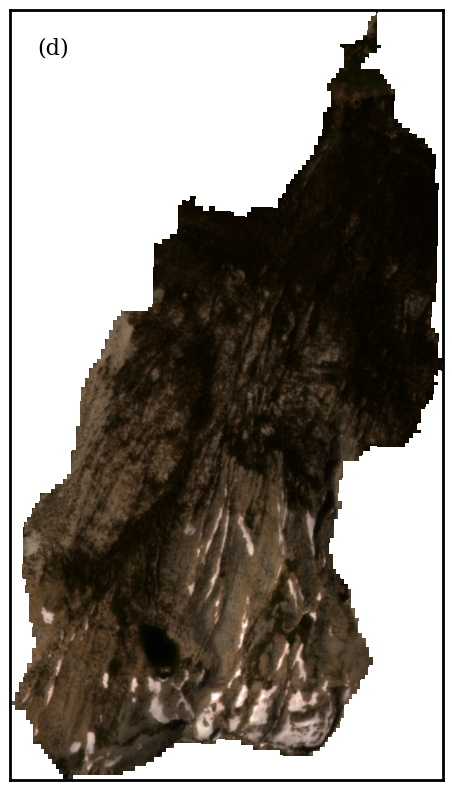

In [24]:

data_direc = f'/data0/images/planet/emma/planet/BUDD/'
year = '2023'
subdirecs = sorted([d for d in glob.glob(data_direc + str(year) + '*') if os.path.isdir(d)])
for dCount,direcc in enumerate(subdirecs):
    if '20230829_183119_13_2488' in direcc:
        fname = glob.glob(direcc+'/*/PSScene/*SR_clip.tif')[0]
        code = direcc.split('/')[-1]
        # if direcc not in filtered_scenes:

        image = rxr.open_rasterio(fname).rio.clip(basin.geometry, drop=True, all_touched=True)
        _,_,_,_,rgb_image = calc_rgb(image)
        rgb_image = np.where(rgb_image == 0, np.nan, rgb_image)
        #plot 
        fig, ax = plt.subplots(figsize=(10, 10))
        plt.rcParams['font.family'] = 'serif'
        ax.imshow(rgb_image, cmap='gray')
        #set background color to white
        ax.set_facecolor('white')
        ax.set_xticks([])
        ax.set_yticks([])
        # box thicker
        ax.spines['top'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    

        
    
        ax.set_title(f"", fontsize=16)
        # add text inside 
        ax.text(0.1, 0.95, f'(d)', fontsize=16, color='black', ha='center', va='center', transform=ax.transAxes)
        #save figure
        # plt.savefig(f'/home/etboud/projects/figures/BUDD_{year}_{code}_shadow.png', bbox_inches='tight', dpi=400)

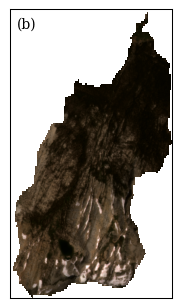

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Set figure size to match half page (≈1122 px at 300 dpi)
fig_width_in = 1122 / 300  # ≈ 3.74 inches
fig_height_in = 1122 / 300  # make it square; adjust if needed
dpi = 1000

fig, ax = plt.subplots(figsize=(3.25,3.75))

# Plot RGB image
ax.imshow(rgb_image, cmap='gray')

# Remove axis ticks
ax.set_xticks([])
ax.set_yticks([])

# Set white background
ax.set_facecolor('white')

# Thicker box
for spine in ax.spines.values():
    spine.set_linewidth(.75)

# Add label inside image
ax.text(0.1, 0.95, '(b)', fontsize=10, color='black', 
        ha='center', va='center', transform=ax.transAxes)

# Save at 300 dpi, tight bounding box
plt.savefig('/home/etboud/projects/figures/Figure_5S_20230829_183119_13_2488.png', 
            dpi=dpi, bbox_inches='tight')
# plt.close(fig)

In [21]:
low_overlap = pd.read_csv(f'/data0/images/planet/emma/planet/{name}/low_overlap_files_95.csv')
filtered_scenes = low_overlap['base_name'].tolist()

In [39]:
import os
import json
import glob
import rioxarray as rxr
def count_quality_categories(root_dir):
    test_count = 0
    standard_count = 0
    test_ids = []
    standard_ids = []
    for foldername, subfolders, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('_metadata.json'):
                filepath = os.path.join(foldername, filename)
                try:
                    with open(filepath, 'r') as f:
                        data = json.load(f)
                    quality = data.get('properties', {}).get('quality_category')
                    file_id = filename.split('_metadata.json')[0]
                                        # Skip if in filtered_scenes
                    if file_id in filtered_scenes:
                        continue

                    if quality == 'test':
                        test_count += 1
                        test_ids.append(file_id)
                    elif quality == 'standard':
                        standard_count += 1
                        standard_ids.append(file_id)
                except Exception as e:
                    print(f"[ERROR] Could not read {filepath}: {e}")
    print(f"Total 'test' files: {test_count}")
    print(f"Test IDs: {test_ids}")
    print(f"\nTotal 'standard' files: {standard_count}")
    print(f"Standard IDs: {standard_ids}")
    return test_ids, standard_ids


def plot_test_images(test_ids, year, data_direc):
    for code in test_ids:
        subdirs = sorted([d for d in glob.glob(os.path.join(data_direc, f"{year}*")) if os.path.isdir(d)])
        for direc in subdirs:
            if code in direc:
                try:
                    tif_path = glob.glob(os.path.join(direc, '*/PSScene/*SR_clip.tif'))[0]
                    image = rxr.open_rasterio(tif_path).rio.clip(basin.geometry, drop=True, all_touched=True)
                    _, _, _, _, rgb_image = calc_rgb(image)
                    rgb_image = np.where(rgb_image == 0, np.nan, rgb_image)

                    fig, ax = plt.subplots(figsize=(10, 10))
                    ax.imshow(rgb_image, cmap='gray')  # normalize if needed
                    ax.set_facecolor('white')
                    ax.set_xticks([])
                    ax.set_yticks([])
                    for spine in ax.spines.values():
                        spine.set_linewidth(2)

                    ax.set_title(f"{code}", fontsize=14)
                    plt.show()

                except IndexError:
                    print(f"[WARNING] No SR_clip.tif found for {code}")
                except Exception as e:
                    print(f"[ERROR] Could not process {code}: {e}")

# Run
test_ids, _ = count_quality_categories(data_direc)
# plot_test_images(test_ids, year='2023', data_direc=data_direc)

Total 'test' files: 59
Test IDs: ['20230415_175204_55_24be', '20220408_174713_79_242b', '20230426_174533_77_2451', '20230426_174533_77_2451', '20230520_174147_45_2423', '20230520_174147_45_2423', '20230402_182234_68_2489', '20220410_182041_43_249b', '20200524_182507_1039', '20220327_180950_52_222f', '20220530_181841_82_2438', '20220520_181225_38_2231', '20220403_174654_26_2451', '20200326_163306_1048', '20220514_175053_78_2427', '20220504_183833_07_2403', '20220401_182254_09_248c', '20220502_175034_31_241f', '20220504_174505_58_2447', '20220406_181919_27_2473', '20230426_174658_30_241e', '20230426_174658_30_241e', '20220519_181736_12_248b', '20220502_174325_73_2445', '20220501_174721_30_245d', '20220506_182131_16_2484', '20200411_163122_0f49', '20220518_182210_98_249b', '20220420_182139_58_2490', '20220601_183818_04_2413', '20230414_182544_78_2446', '20230405_174946_07_2415', '20220519_174722_00_2420', '20220503_175011_14_2435', '20220523_174711_38_241f', '20220504_175147_99_242d', '20

In [29]:
def build_scene_dataframe(root_dir, filtered_scenes):
    data = []
    skipped_count = 0  # ← Track how many are skipped

    for foldername, subfolders, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('_metadata.json'):
                file_id = filename.split('_metadata.json')[0]

                if file_id in filtered_scenes:
                    skipped_count += 1  # ← Count skipped
                    continue

                filepath = os.path.join(foldername, filename)
                try:
                    with open(filepath, 'r') as f:
                        metadata = json.load(f)
                    quality = metadata.get('properties', {}).get('quality_category')

                    # Try to find matching SR_clip.tif file and extract date
                    tifs = glob.glob(os.path.join(foldername, '*SR_clip.tif'))
                    if tifs:
                        tif_name = os.path.basename(tifs[0])
                        date_str = tif_name.split('_')[0]
                        date = pd.to_datetime(date_str, format='%Y%m%d')
                        data.append({'id': file_id, 'date': date, 'quality': quality})
                except Exception as e:
                    print(f"[ERROR] {file_id}: {e}")

    print(f"Skipped {skipped_count} scenes that were in filtered_scenes")
    return pd.DataFrame(data)

In [114]:
df = build_scene_dataframe(data_direc, filtered_scenes)

In [ ]:
(df['quality'] == 'test').sum()

59

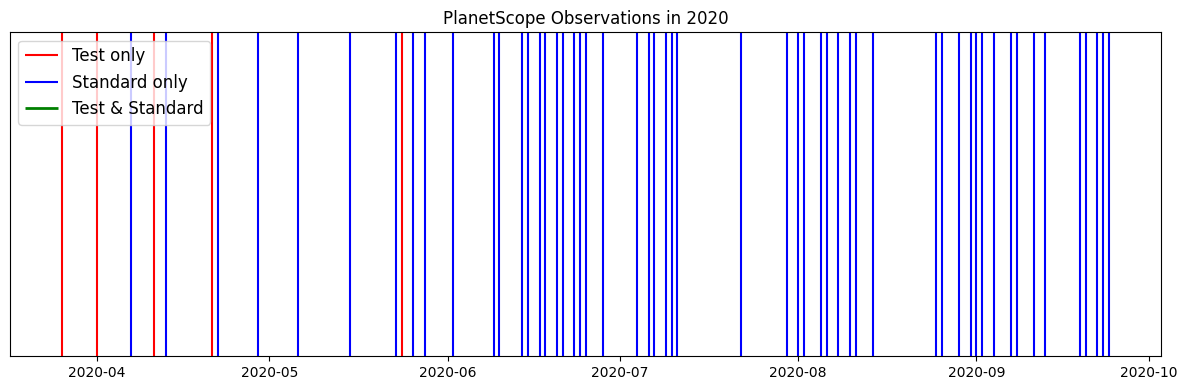

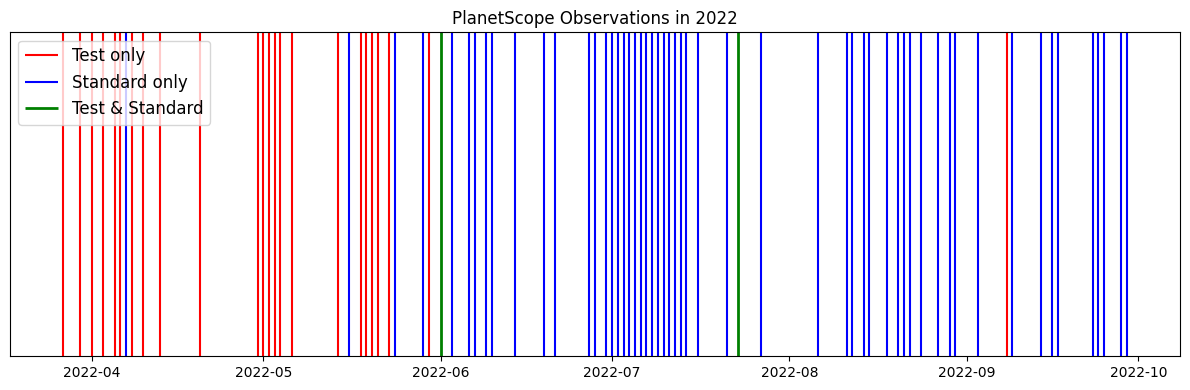

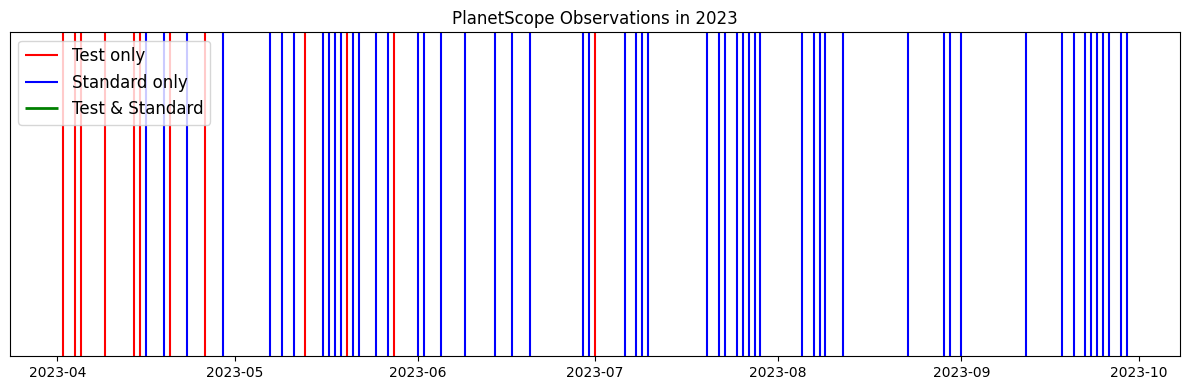

In [38]:

# Step 1: Build DataFrame with ID, date, and quality
def build_scene_dataframe(root_dir, filtered_scenes):
    data = []
    for foldername, subfolders, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('_metadata.json'):
                file_id = filename.split('_metadata.json')[0]
                if file_id in filtered_scenes:
                    continue
                filepath = os.path.join(foldername, filename)
                try:
                    with open(filepath, 'r') as f:
                        metadata = json.load(f)
                    quality = metadata.get('properties', {}).get('quality_category')

                    # Try to find matching SR_clip.tif file and extract date
                    tifs = glob.glob(os.path.join(foldername, '*SR_clip.tif'))
                    if tifs:
                        tif_name = os.path.basename(tifs[0])
                        date_str = tif_name.split('_')[0]
                        date = pd.to_datetime(date_str, format='%Y%m%d')
                        data.append({'id': file_id, 'date': date, 'quality': quality})
                except Exception as e:
                    print(f"[ERROR] {file_id}: {e}")
    return pd.DataFrame(data)

def plot_by_year(df):
    df['year'] = df['date'].dt.year
    years = sorted(df['year'].unique())

    for year in years:
        df_year = df[df['year'] == year]

        # Step 1: Group by date and check what categories are present
        grouped = df_year.groupby('date')['quality'].unique()
        both_dates = grouped[grouped.apply(lambda x: set(x) == {'test', 'standard'})].index
        test_only_dates = grouped[grouped.apply(lambda x: x.tolist() == ['test'])].index
        standard_only_dates = grouped[grouped.apply(lambda x: x.tolist() == ['standard'])].index

        # Step 2: Plot
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.vlines(test_only_dates, ymin=0, ymax=1, color='red', label='Test only')
        ax.vlines(standard_only_dates, ymin=0, ymax=1, color='blue', label='Standard only')
        ax.vlines(both_dates, ymin=0, ymax=1, color='green', linewidth=2, label='Test & Standard')

        ax.set_title(f"PlanetScope Observations in {year}")
        ax.set_yticks([])
        ax.set_ylim(0, 1)
        legend = ax.legend(loc='upper left',fontsize=12)
        legend.set_alpha(1)
        plt.tight_layout()
        plt.show()
df = build_scene_dataframe(data_direc, filtered_scenes)
plot_by_year(df)



In [40]:
# how many test before june for all 3 years
test_before_june = df[(df['quality'] == 'test') & (df['date'].dt.month < 6)]

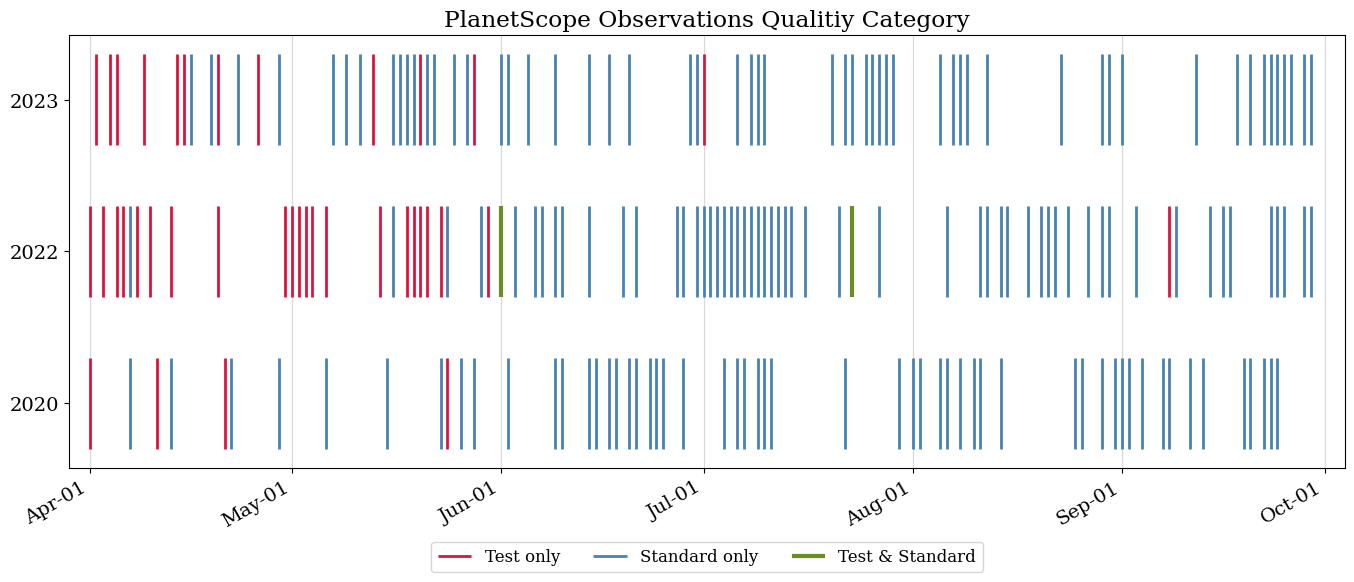

In [ ]:
def plot_stacked(df):
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month_day'] = df['date'].apply(lambda d: pd.Timestamp(year=2000, month=d.month, day=d.day))

    cutoff = pd.Timestamp('2000-04-01')
    df = df[df['month_day'] >= cutoff]

    years = sorted(df['year'].unique())

    fig, ax = plt.subplots(figsize=(14, 6))
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.size'] = 14
    y_ticks = []
    y_labels = []

    line_height = 0.3

    for i, year in enumerate(years):
        df_year = df[df['year'] == year]

        grouped = df_year.groupby('month_day')['quality'].unique()

        both_dates = grouped[grouped.apply(lambda x: set(x) == {'test', 'standard'})].index
        test_only_dates = grouped[grouped.apply(lambda x: list(x) == ['test'])].index
        standard_only_dates = grouped[grouped.apply(lambda x: list(x) == ['standard'])].index

        y = i

        ax.vlines(test_only_dates, ymin=y - line_height, ymax=y + line_height, color='crimson', label='Test only' if i == 0 else "", linewidth=2)
        ax.vlines(standard_only_dates, ymin=y - line_height, ymax=y + line_height, color='steelblue', label='Standard only' if i == 0 else "", linewidth=2)
        ax.vlines(both_dates, ymin=y - line_height, ymax=y + line_height, color='olivedrab', label='Test & Standard' if i == 0 else "", linewidth=3)

        y_ticks.append(y)
        y_labels.append(str(year))

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    #extend y lim
    

    # Set x-axis limits with padding BEFORE cutoff date
    x_start = pd.Timestamp('2000-03-29')
    x_end = pd.Timestamp('2000-10-04')
    ax.set_xlim(x_start, x_end)
    # verticlegridlines
    ax.xaxis.grid(True, alpha=0.5)

    ax.set_title('PlanetScope Observations Qualitiy Category')
    #legend outside top 3 column
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -.15), ncol=3, fontsize=12)
    plt.tight_layout()

    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b-%d'))
    fig.autofmt_xdate()
    # plt.savefig(f'/home/etboud/projects/figures/planet_quality_stacked.png', bbox_inches='tight', dpi=400)

    
fig  = plot_stacked(df)

In [117]:
# how many test before after april 1 and before june for all 3 years
len(df[(df['date'].dt.month > 3) & (df['quality'] == 'standard')])

224

In [113]:
year = '2023'
data_direc = f'/data0/images/planet/emma/planet/{name}/'
fn = f'/home/etboud/projects/data/stacks/sep/{name}_base_{year}_projected.nc'
pp_fn = f'/home/etboud/projects/data/stacks/sep/{name}_baseS_{year}_3_30.nc'
comp_fn = f'/home/etboud/projects/data/stacks/sep/{name}_composite_{year}_projected.nc'



ps = xr.open_dataset(fn)
pp = xr.open_dataset(pp_fn)
comp = xr.open_dataset(comp_fn)
len(ps['time'])
ps['time']

<xarray.DataArray 'time' (time: 85)> Size: 680B
array(['2023-04-02T00:00:00.000000000', '2023-04-04T00:00:00.000000000',
       '2023-04-04T00:00:00.000000000', '2023-04-04T00:00:00.000000000',
       '2023-04-05T00:00:00.000000000', '2023-04-05T00:00:00.000000000',
       '2023-04-09T00:00:00.000000000', '2023-04-14T00:00:00.000000000',
       '2023-04-15T00:00:00.000000000', '2023-04-16T00:00:00.000000000',
       '2023-04-19T00:00:00.000000000', '2023-04-20T00:00:00.000000000',
       '2023-04-23T00:00:00.000000000', '2023-04-23T00:00:00.000000000',
       '2023-04-26T00:00:00.000000000', '2023-04-26T00:00:00.000000000',
       '2023-04-29T00:00:00.000000000', '2023-04-29T00:00:00.000000000',
       '2023-05-07T00:00:00.000000000', '2023-05-09T00:00:00.000000000',
       '2023-05-11T00:00:00.000000000', '2023-05-11T00:00:00.000000000',
       '2023-05-13T00:00:00.000000000', '2023-05-16T00:00:00.000000000',
       '2023-05-17T00:00:00.000000000', '2023-05-17T00:00:00.000000000',
       '2023-05-18T00:00:00.000000000', '2023-05-18T00:00:00.000000000',
       '2023-05-19T00:00:00.000000000', '2023-05-19T00:00:00.000000000',
       '2023-05-20T00:00:00.000000000', '2023-05-21T00:00:00.000000000',
       '2023-05-22T00:00:00.000000000', '2023-05-24T00:00:00.000000000',
       '2023-05-25T00:00:00.000000000', '2023-05-27T00:00:00.000000000',
       '2023-05-27T00:00:00.000000000', '2023-05-28T00:00:00.000000000',
       '2023-06-01T00:00:00.000000000', '2023-06-02T00:00:00.000000000',
       '2023-06-02T00:00:00.000000000', '2023-06-05T00:00:00.000000000',
       '2023-06-09T00:00:00.000000000', '2023-06-14T00:00:00.000000000',
       '2023-06-17T00:00:00.000000000', '2023-06-20T00:00:00.000000000',
       '2023-06-29T00:00:00.000000000', '2023-06-30T00:00:00.000000000',
       '2023-07-01T00:00:00.000000000', '2023-07-06T00:00:00.000000000',
       '2023-07-08T00:00:00.000000000', '2023-07-08T00:00:00.000000000',
       '2023-07-09T00:00:00.000000000', '2023-07-10T00:00:00.000000000',
       '2023-07-20T00:00:00.000000000', '2023-07-22T00:00:00.000000000',
       '2023-07-23T00:00:00.000000000', '2023-07-25T00:00:00.000000000',
       '2023-07-26T00:00:00.000000000', '2023-07-27T00:00:00.000000000',
       '2023-07-28T00:00:00.000000000', '2023-07-29T00:00:00.000000000',
       '2023-07-29T00:00:00.000000000', '2023-08-05T00:00:00.000000000',
       '2023-08-07T00:00:00.000000000', '2023-08-08T00:00:00.000000000',
       '2023-08-09T00:00:00.000000000', '2023-08-12T00:00:00.000000000',
       '2023-08-23T00:00:00.000000000', '2023-08-29T00:00:00.000000000',
       '2023-08-30T00:00:00.000000000', '2023-09-01T00:00:00.000000000',
       '2023-09-12T00:00:00.000000000', '2023-09-18T00:00:00.000000000',
       '2023-09-20T00:00:00.000000000', '2023-09-22T00:00:00.000000000',
       '2023-09-23T00:00:00.000000000', '2023-09-23T00:00:00.000000000',
       '2023-09-24T00:00:00.000000000', '2023-09-25T00:00:00.000000000',
       '2023-09-25T00:00:00.000000000', '2023-09-26T00:00:00.000000000',
       '2023-09-26T00:00:00.000000000', '2023-09-28T00:00:00.000000000',
       '2023-09-29T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 680B 2023-04-02 2023-04-04 ... 2023-09-29